In [1]:
import sys
import os
import jax
import jax.numpy as np
import amigo
import ehtplot
import scienceplots
import cmasher
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
from dLux import utils as dlu
from zodiax.optimisation import sgd, adam
import dorito

# Basic jax import
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_debug_nans", False)

# # Check if running on remote, and set directory to where notebook is run
# if jax.devices()[0].platform == "gpu":
#     os.chdir("code/amigo_project/notebooks/calibration")

# Add parent directories
paths = [os.path.abspath(os.path.join(os.getcwd(), path)) for path in ['..', "../.."]]
for path in paths:
    if path not in sys.path:
        sys.path.insert(0, path)
        
# Plotting set up
%matplotlib inline
plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

plt.style.use(["science", "bright", "no-latex"])

inferno = mpl.colormaps["inferno"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]
inferno.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)


def merge_cbar(ax):
    return make_axes_locatable(ax).append_axes("right", size="5%", pad=0.0)

In [2]:
from socket import gethostname

if gethostname() == "glinton":
    morgana = "/media/morgana1/"
else:
    morgana = "/Volumes/morgana1/"

data_path = os.path.join(morgana, "snert/max/data/JWST/WR137/calslope/")
uncal_path = os.path.join(morgana, "snert/max/data/JWST/WR137/uncal/")
amigo_cache = os.path.join(morgana, "snert/max/data/amigo_files/")

cache = os.path.join(amigo_cache, "cal_files/")
output_path = os.path.join(amigo_cache, "outputs/WR137/")
fig_path = os.path.join(amigo_cache, "figs/")


EXP_TYPE = "NIS_AMI"
FILTERS = [
    "F480M",
    "F430M",
    "F380M",
    # "F277W",
]

# Bind file path, type and exposure type
file_fn = lambda data_path, filters=FILTERS, **kwargs: amigo.files.get_files(
    # "/Users/mcha5804/JWST/ERS1373/calgrps/",
    data_path,
    "calslope",
    EXP_TYPE=EXP_TYPE,
    FILTER=filters,
    **kwargs,
)

files = sorted(
    file_fn(data_path), key=lambda hdu: hdu[0].header.get("EXPMID", float("inf"))
)

WR137AMIREFPSF
1


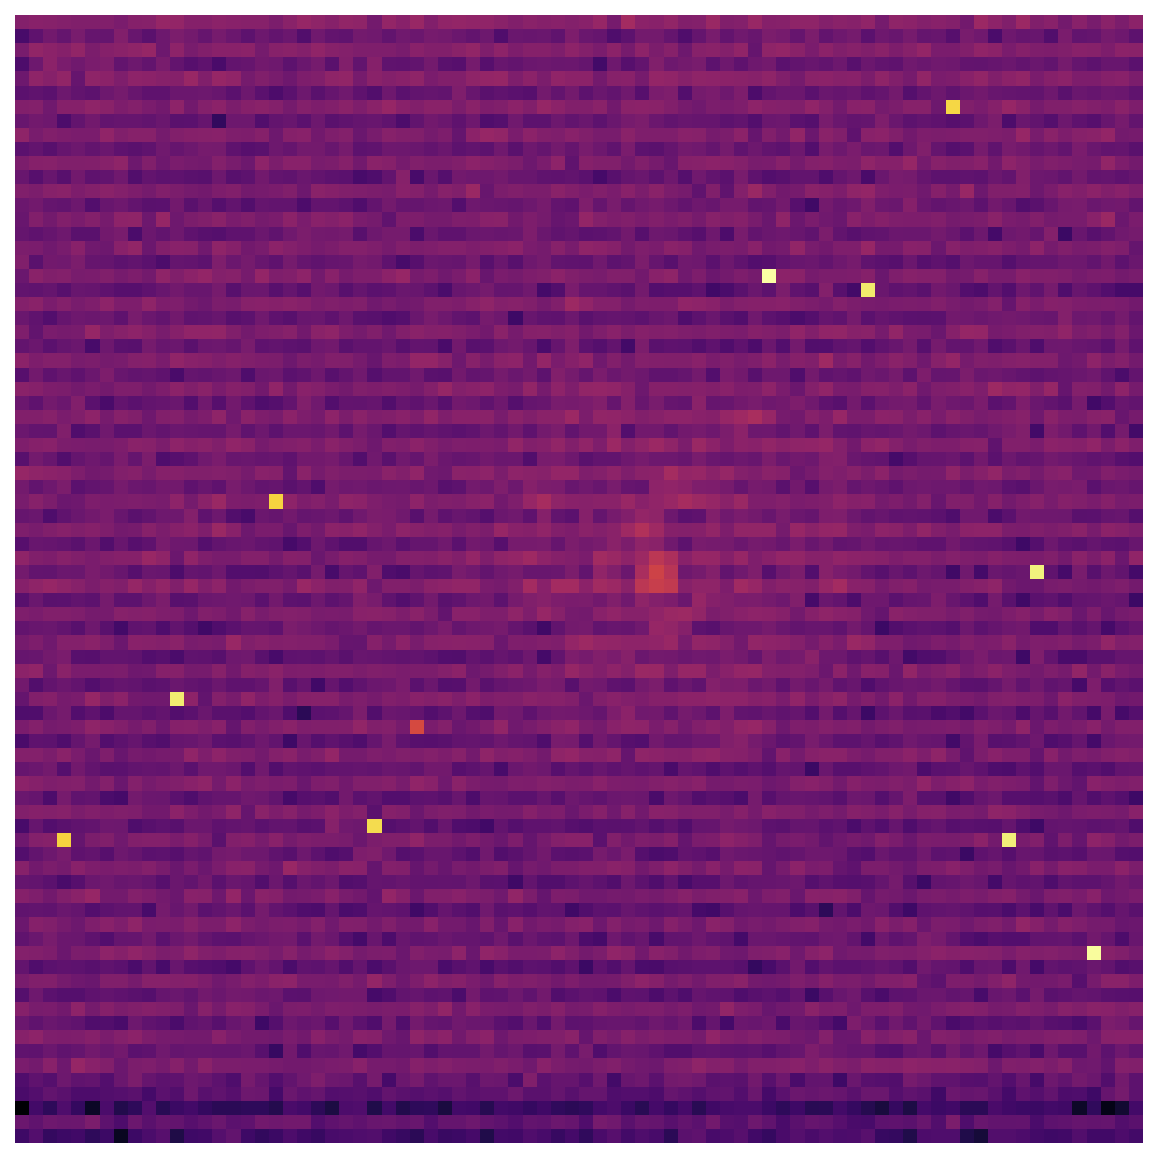

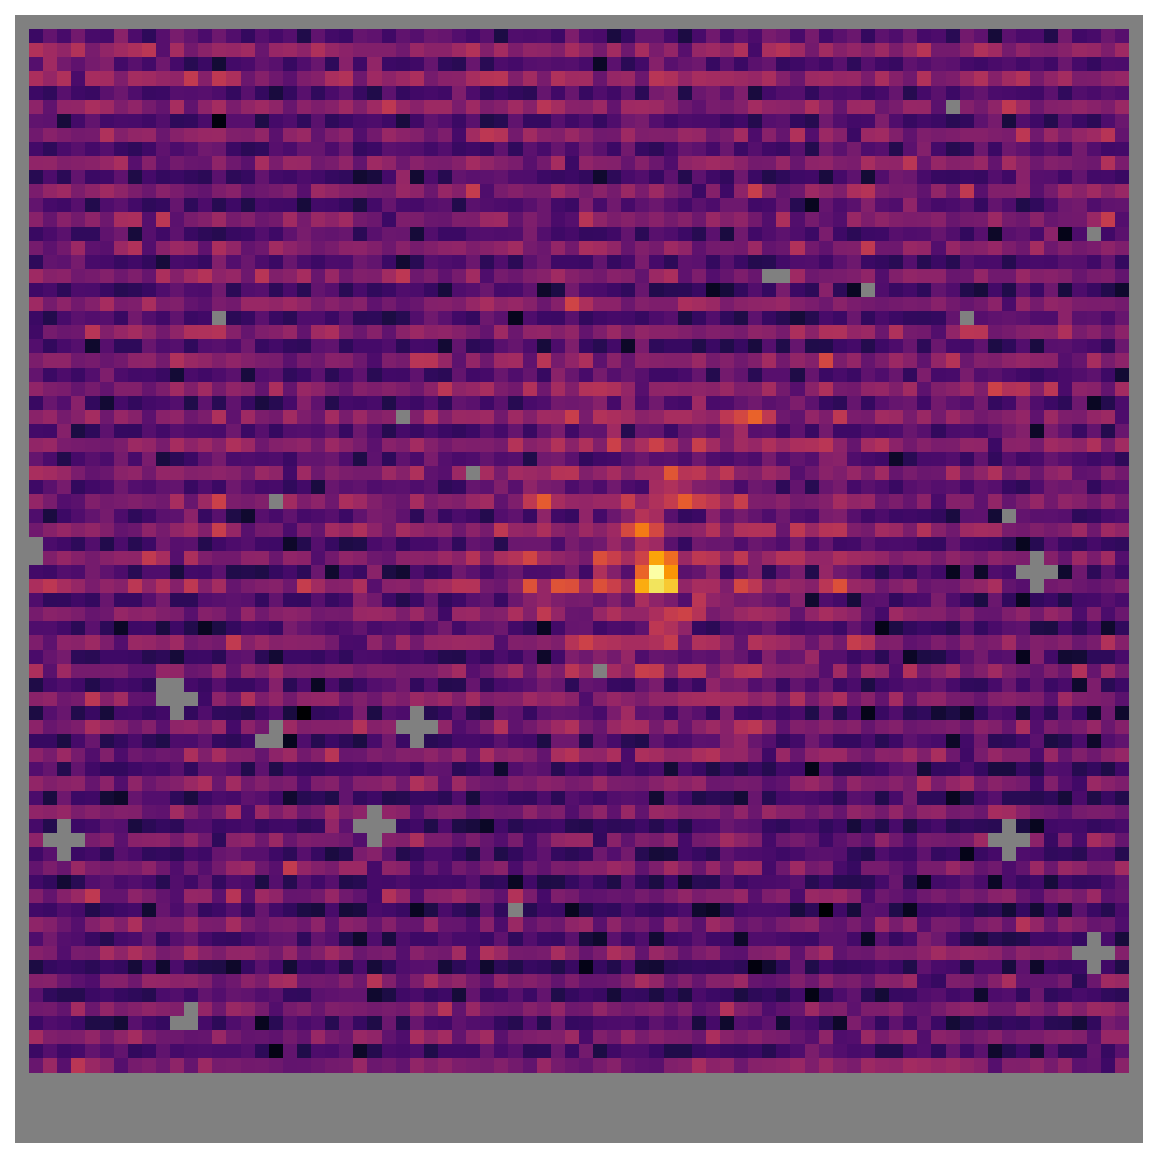

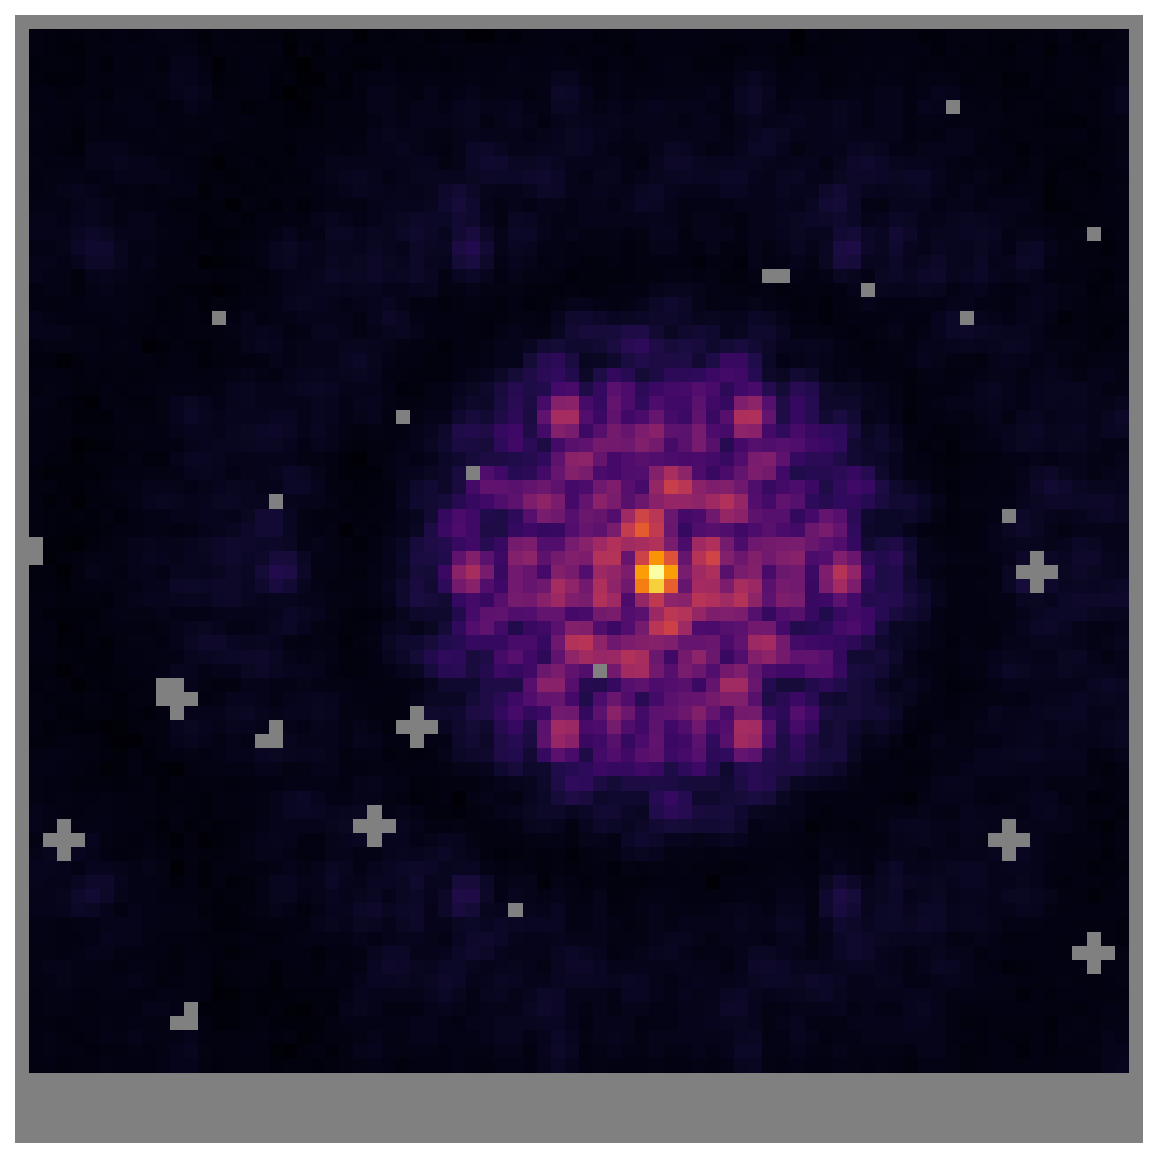

In [59]:
from astropy.io import fits

exposures = [amigo.model_fits.PointFit(file) for file in files]


for uncal in os.listdir(uncal_path):
    if uncal.startswith("."):
        continue

    uncal_file = fits.open(os.path.join(uncal_path, uncal))

    if uncal_file[0].header["TARGPROP"] != "WR137AMIREFPSF":
        continue

    if uncal_file[0].header["PATT_NUM"] == 1:
        break

print(uncal_file[0].header["TARGPROP"])
print(uncal_file[0].header["PATT_NUM"])

for exp in exposures:
    if not exp.calibrator:
        continue
    if exp.dither == "1":
        break


plt.figure(figsize=(4, 4))
plt.imshow(uncal_file["SCI"].data[0, -1], norm=mpl.colors.PowerNorm(0.5))
plt.axis("off")
plt.tight_layout()
plt.savefig(fig_path + "uncal.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(4, 4))
plt.imshow(np.where(~exp.badpix, exp.ramp[-1], np.nan), inferno)
plt.axis("off")
plt.tight_layout()
plt.savefig(fig_path + "calramp.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(4, 4))
plt.imshow(
    np.where(~exp.badpix, exp.slopes[-1], np.nan),
    inferno,
    norm=mpl.colors.PowerNorm(0.5),
)
plt.axis("off")
plt.tight_layout()
plt.savefig(fig_path + "calslope.png", dpi=300, bbox_inches="tight")
plt.show()

# Log Amplitudes and phases

In [4]:
# from amigo.misc import tqdm
# import zodiax as zdx

# # from amigo.vis_models import model_vis_psf
# from amigo.stats import batched_jacobian, decompose
# import dLux.utils as dlu

# do_calcs = False

# optics = amigo.optical_models.AMIOptics()
# if do_calcs:
#     n_terms = 250
#     eig_mats = {"amplitude": {}, "phase": {}}

# else:
#     print("is this taking ages")
#     eig_mats = zdx.experimental.deserialise(K_path + "eigmats.zdx")
#     print("this is taking ages")
#     amp_vals = np.load(K_path + "ampvals.npy")
#     amp_vecs = np.load(K_path + "ampvecs.npy")
#     phase_vals = np.load(K_path + "phasevals.npy")
#     phase_vecs = np.load(K_path + "phasevecs.npy")
#     H_amp = np.load(K_path + "H_amp.npy")
#     H_phase = np.load(K_path + "H_phase.npy")

In [5]:
optics = amigo.optical_models.AMIOptics()
optics2 = amigo.optical_models.AMIOptics(static=False)

In [6]:
mask = optics.pupil_mask.transmission
holes = optics2.holes

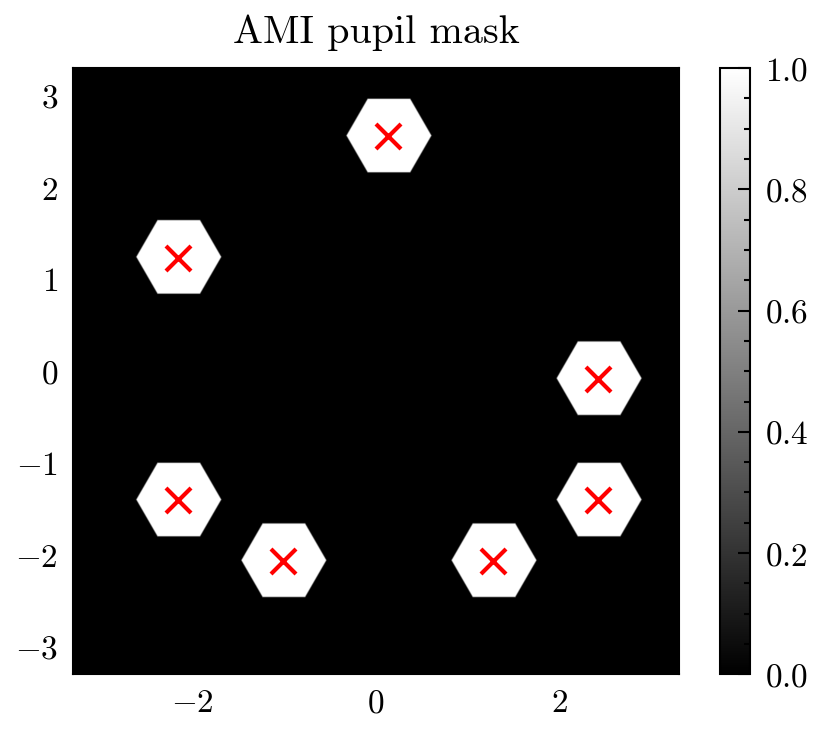

In [7]:
d = optics.diameter
extent = (-d / 2, d / 2, -d / 2, d / 2)

plt.scatter(holes.T[0], holes.T[1], marker="x", color="red")
plt.imshow(mask, cmap="gray", extent=extent)
plt.colorbar()
plt.title("AMI pupil mask")
plt.show()

In [8]:
# from amigo.vis_models import vis_to_im

# plt.figure(figsize=(25, 8))
# for i in range(5):
#     log_amp, phase = vis_to_im(amp_vecs[i], phase_vecs[i], (51, 51))

#     v = np.nanmax(np.abs(log_amp))
#     plt.subplot(2, 5, i + 1)
#     plt.imshow(log_amp, seismic, vmin=-v, vmax=v)
#     plt.colorbar()

#     v = np.nanmax(np.abs(phase))
#     plt.subplot(2, 5, i + 6)
#     plt.imshow(phase, seismic, vmin=-v, vmax=v)
#     plt.colorbar()

# plt.tight_layout()
# plt.show()

In [9]:
# n_basis = 150

# plt.figure(figsize=(25, 8))
# for i in range(5):
#     latent_amp, latent_phase = jr.normal(jr.key(i), (2, n_basis))
#     log_amp = np.dot(latent_amp, amp_vecs[:n_basis])
#     phase = np.dot(latent_phase, phase_vecs[:n_basis])
#     log_amp, phase = vis_to_im(log_amp, phase, (51, 51))

#     v = np.nanmax(np.abs(log_amp))
#     plt.subplot(2, 5, i + 1)
#     plt.imshow(log_amp, seismic, vmin=-v, vmax=v)
#     plt.colorbar()

#     v = np.nanmax(np.abs(phase))
#     plt.subplot(2, 5, i + 6)
#     plt.imshow(phase, seismic, vmin=-v, vmax=v)
#     plt.colorbar()

# plt.tight_layout()
# plt.show()

In [10]:
from amigo.vis_models import LogVisModel

otf_coords = dlu.pixel_coords(51, 2 * optics.diameter)
# vis_model = LogVisModel(
#     eig_mats["amplitude"],
#     eig_mats["phase"],
#     otf_coords,
#     n_terms=480,
# )

In [11]:
load_dict = lambda x: np.load(f"{x}", allow_pickle=True).item()

exposures = [amigo.model_fits.SplineVisFit(file) for file in files]

model = amigo.core_models.AmigoModel(
    exposures,
    # [],
    optics=amigo.optical_models.AMIOptics(),
    detector=amigo.detector_models.SUB80Detector(),
    read=amigo.read_models.ReadModel(),
    vis_model=amigo.vis_models.LogVisModel(
        load_dict(cache + "vis_basis.npy"), n_basis=420
    ),
    state=load_dict(cache + "cal_model.npy"),
)

01349_F380M
01349_F480M


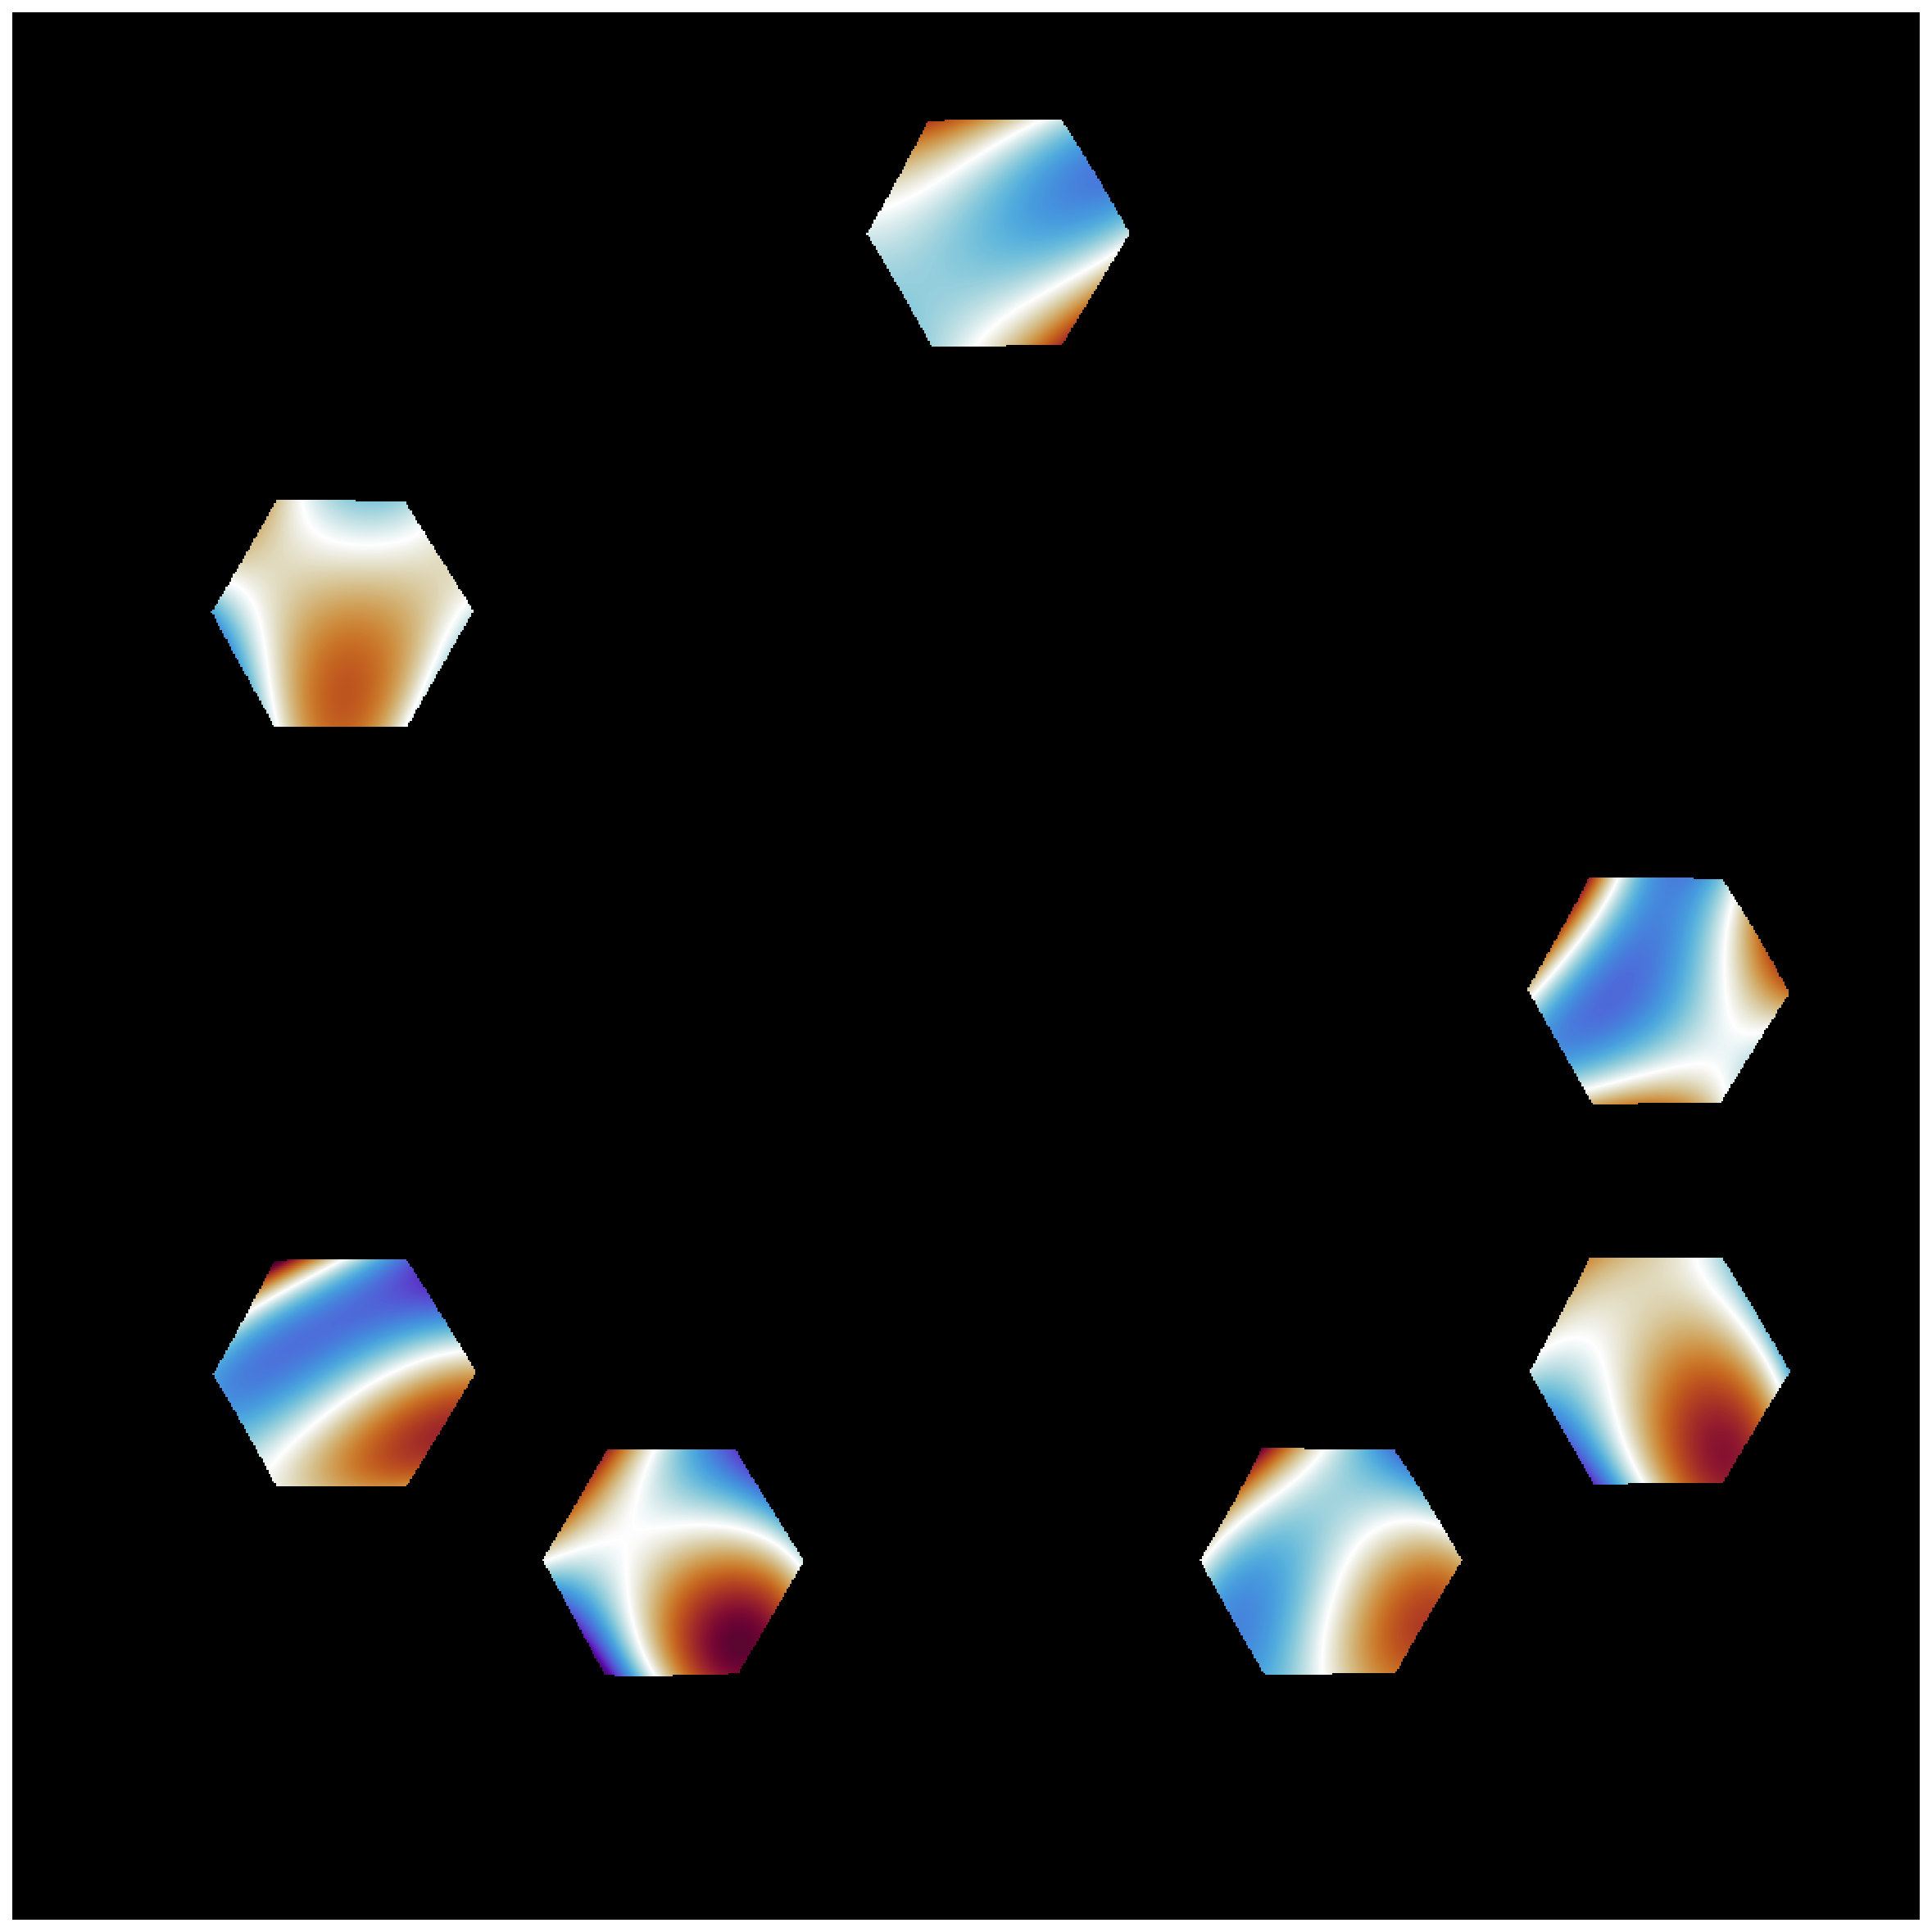

In [12]:
cmap = mpl.colormaps["cmr.fusion"]
cmap.set_bad("k", 1.0)

cal_aberrations = {
    key: val for key, val in model.aberrations.items()
}  # if "04481" in key}

optics = model.optics
pupil_mask = model.optics.pupil_mask

plt.figure(figsize=(8, 8))
# plt.suptitle("Primary Mirror Aberrations")
for i, key in enumerate(cal_aberrations):
    filt = key.split("_")[-1]
    print(key)

    coeffs = model.aberrations[key]
    full_abb = pupil_mask.set("abb_coeffs", coeffs).calc_aberrations()
    flat_abb = pupil_mask.set("abb_coeffs", coeffs.at[:, :3].set(0)).calc_aberrations()

    mask = pupil_mask.transmission

    full_abb = np.where(mask < 1.0, np.nan, 1e9 * full_abb)
    flat_abb = np.where(mask < 1.0, np.nan, 1e9 * flat_abb)

    full_abb -= np.nanmean(full_abb)
    flat_abb -= np.nanmean(flat_abb)

    rms = lambda x: np.sqrt(np.nanmean(np.square(x)))

    v = np.nanmax(np.abs(flat_abb))
    # plt.subplot(1, 3, i + 1)
    # plt.title(f"{filt} - RMS: {rms(flat_abb):.2f} nm")
    plt.imshow(flat_abb, cmap, vmin=-v, vmax=v)
    plt.axis("off")
    # plt.colorbar(label="OPD (nm)")

plt.tight_layout()
# plt.savefig(fig_path + "wavefront.png", dpi=300, bbox_inches="tight")
plt.show()

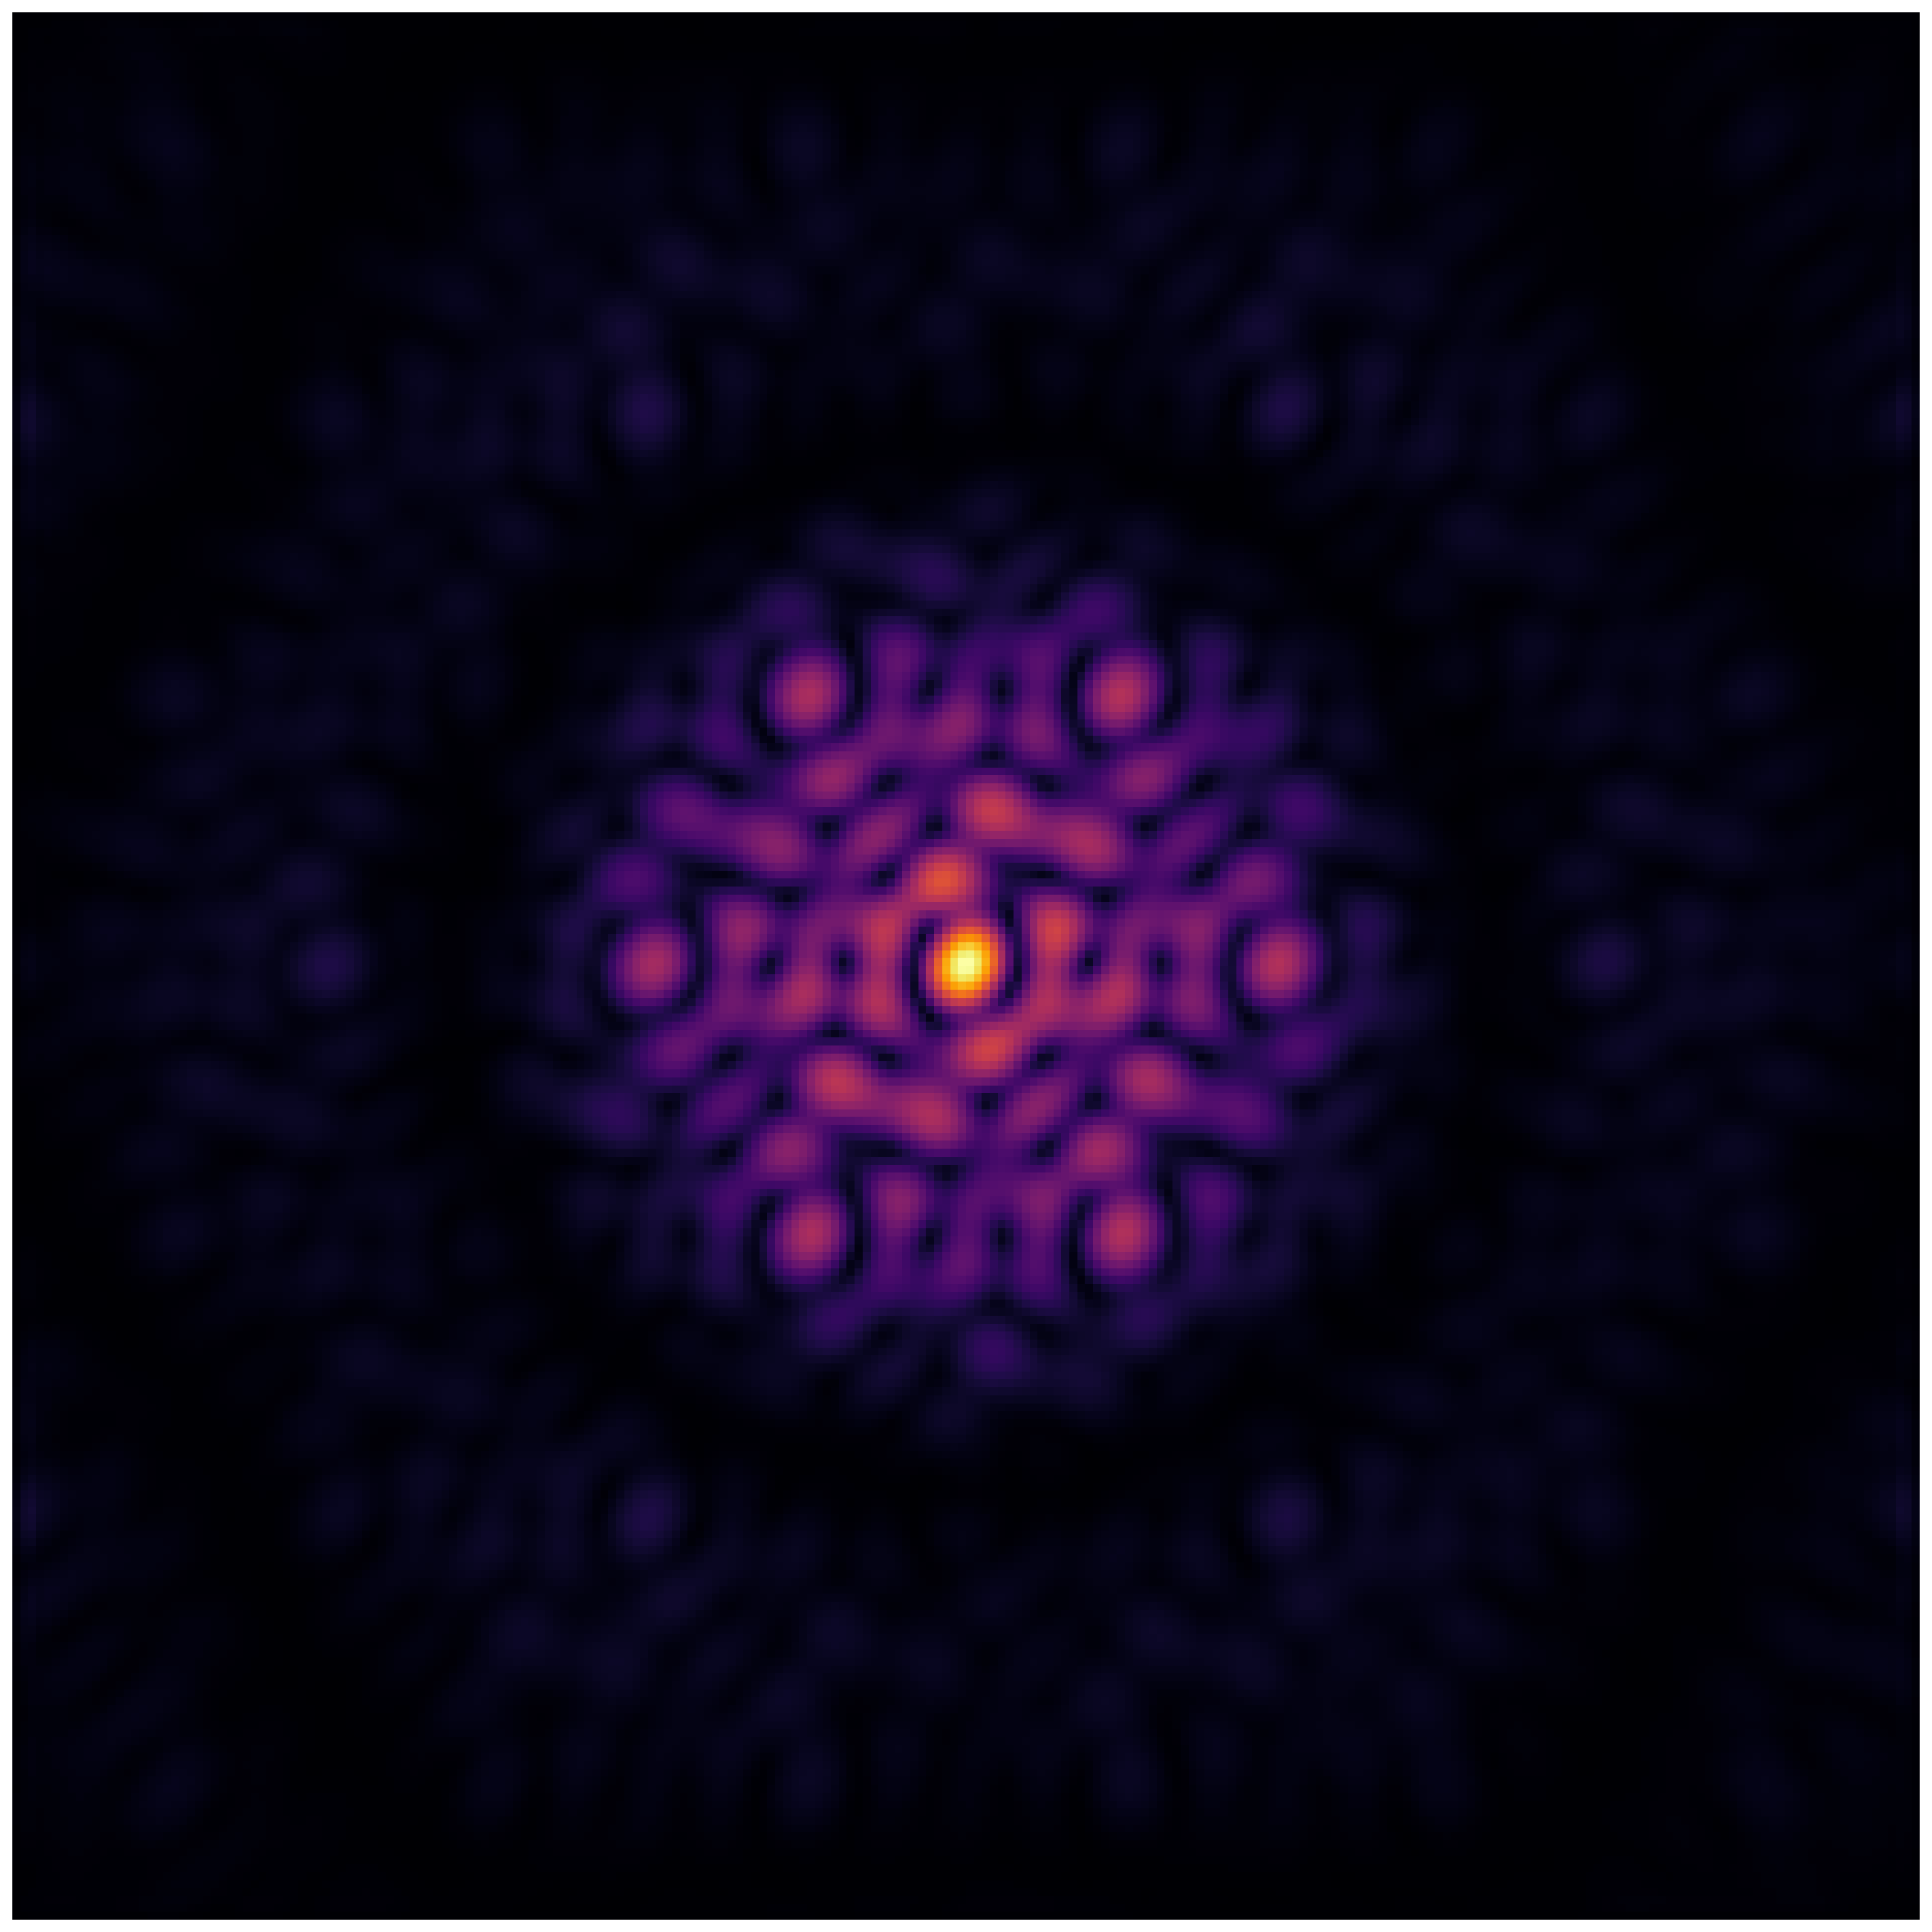

In [13]:
import jax.tree as jtu

exp = exposures[0]

model = model.set("positions", jtu.map(lambda x: 0 * x, model.positions))
psf = exp.model_psf(model)

plt.figure(figsize=(8, 8))
plt.imshow(psf.data, norm=mpl.colors.PowerNorm(0.5), cmap="inferno")
plt.axis("off")
plt.tight_layout()
# plt.savefig(fig_path + "psf.png", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
from amigo.vis_models import wf_fft_coords, vis_to_im
from amigo.misc import interp
from jax import vmap

model = model.set("positions", jtu.map(lambda x: 0 * x, model.positions))
wfs = exp.model_wfs(model)

log_amps_ = np.zeros(model.vis_model.n_basis).at[:10].set(0.1)
phases_ = np.zeros(model.vis_model.n_basis).at[:10].set(0.1)

log_amps = np.dot(log_amps_, model.vis_model.V_amp["F430M"])
phases = np.dot(phases_, model.vis_model.V_phase["F430M"])
log_amps, phase = vis_to_im(log_amps, phases, otf_coords.shape[1:])

print(log_amps.shape, phases.shape)
print(otf_coords.shape)

# Interpolate the visibility maps to uv coordinates
uv_coords = wf_fft_coords(wfs, pad=2)
interp_fn = lambda im, uv: interp(im, otf_coords, uv, method="linear", fill=0.0)
log_amps = vmap(lambda uv: interp_fn(log_amps, uv))(uv_coords)
phases = vmap(lambda uv: interp_fn(phase, uv))(uv_coords)

# Fourier Functions (use 2x pad)
n = uv_coords.shape[-1] // 4
crop_fn = lambda x: x[n:-n, n:-n]
pad_fn = lambda x: np.pad(x, n, mode="constant")
to_uv = vmap(lambda x: np.fft.fftshift(np.fft.fft2(pad_fn(x))))
from_uv = vmap(lambda x: crop_fn(np.fft.ifft2(np.fft.ifftshift(x))))

# Apply the visibility maps
splodges = to_uv(wfs.psf)
# return np.abs(from_uv(splodges)).sum(0)

splodges.shape

(51, 51) (1300,)
(2, 51, 51)


(9, 480, 480)

In [15]:
def model_vis(self, wfs, model):
    # NOTE: Returns a psf

    # Get the visibilities
    amps = model.amplitudes[self.get_key("amplitudes")]
    phases = model.phases[self.get_key("phases")]
    return model.vis_model.model_vis(wfs, amps, phases, self.filter)

In [16]:
exp.get_key("amplitudes")

'WR137_F480M'

In [17]:
model.get(exp.map_param("amplitudes")).shape

(420,)

In [18]:
# p = model.params
# p["amplitudes"]["WR137AMIREFPSF_F480M"] = log_amps
# params["phases"][exp.get_key("phases")] = phases

x = model.set(exp.map_param("amplitudes"), 5 * log_amps_)
x = x.set(exp.map_param("phases"), 2 * phases_)

# intfg = exp.model_vis(wfs, x)

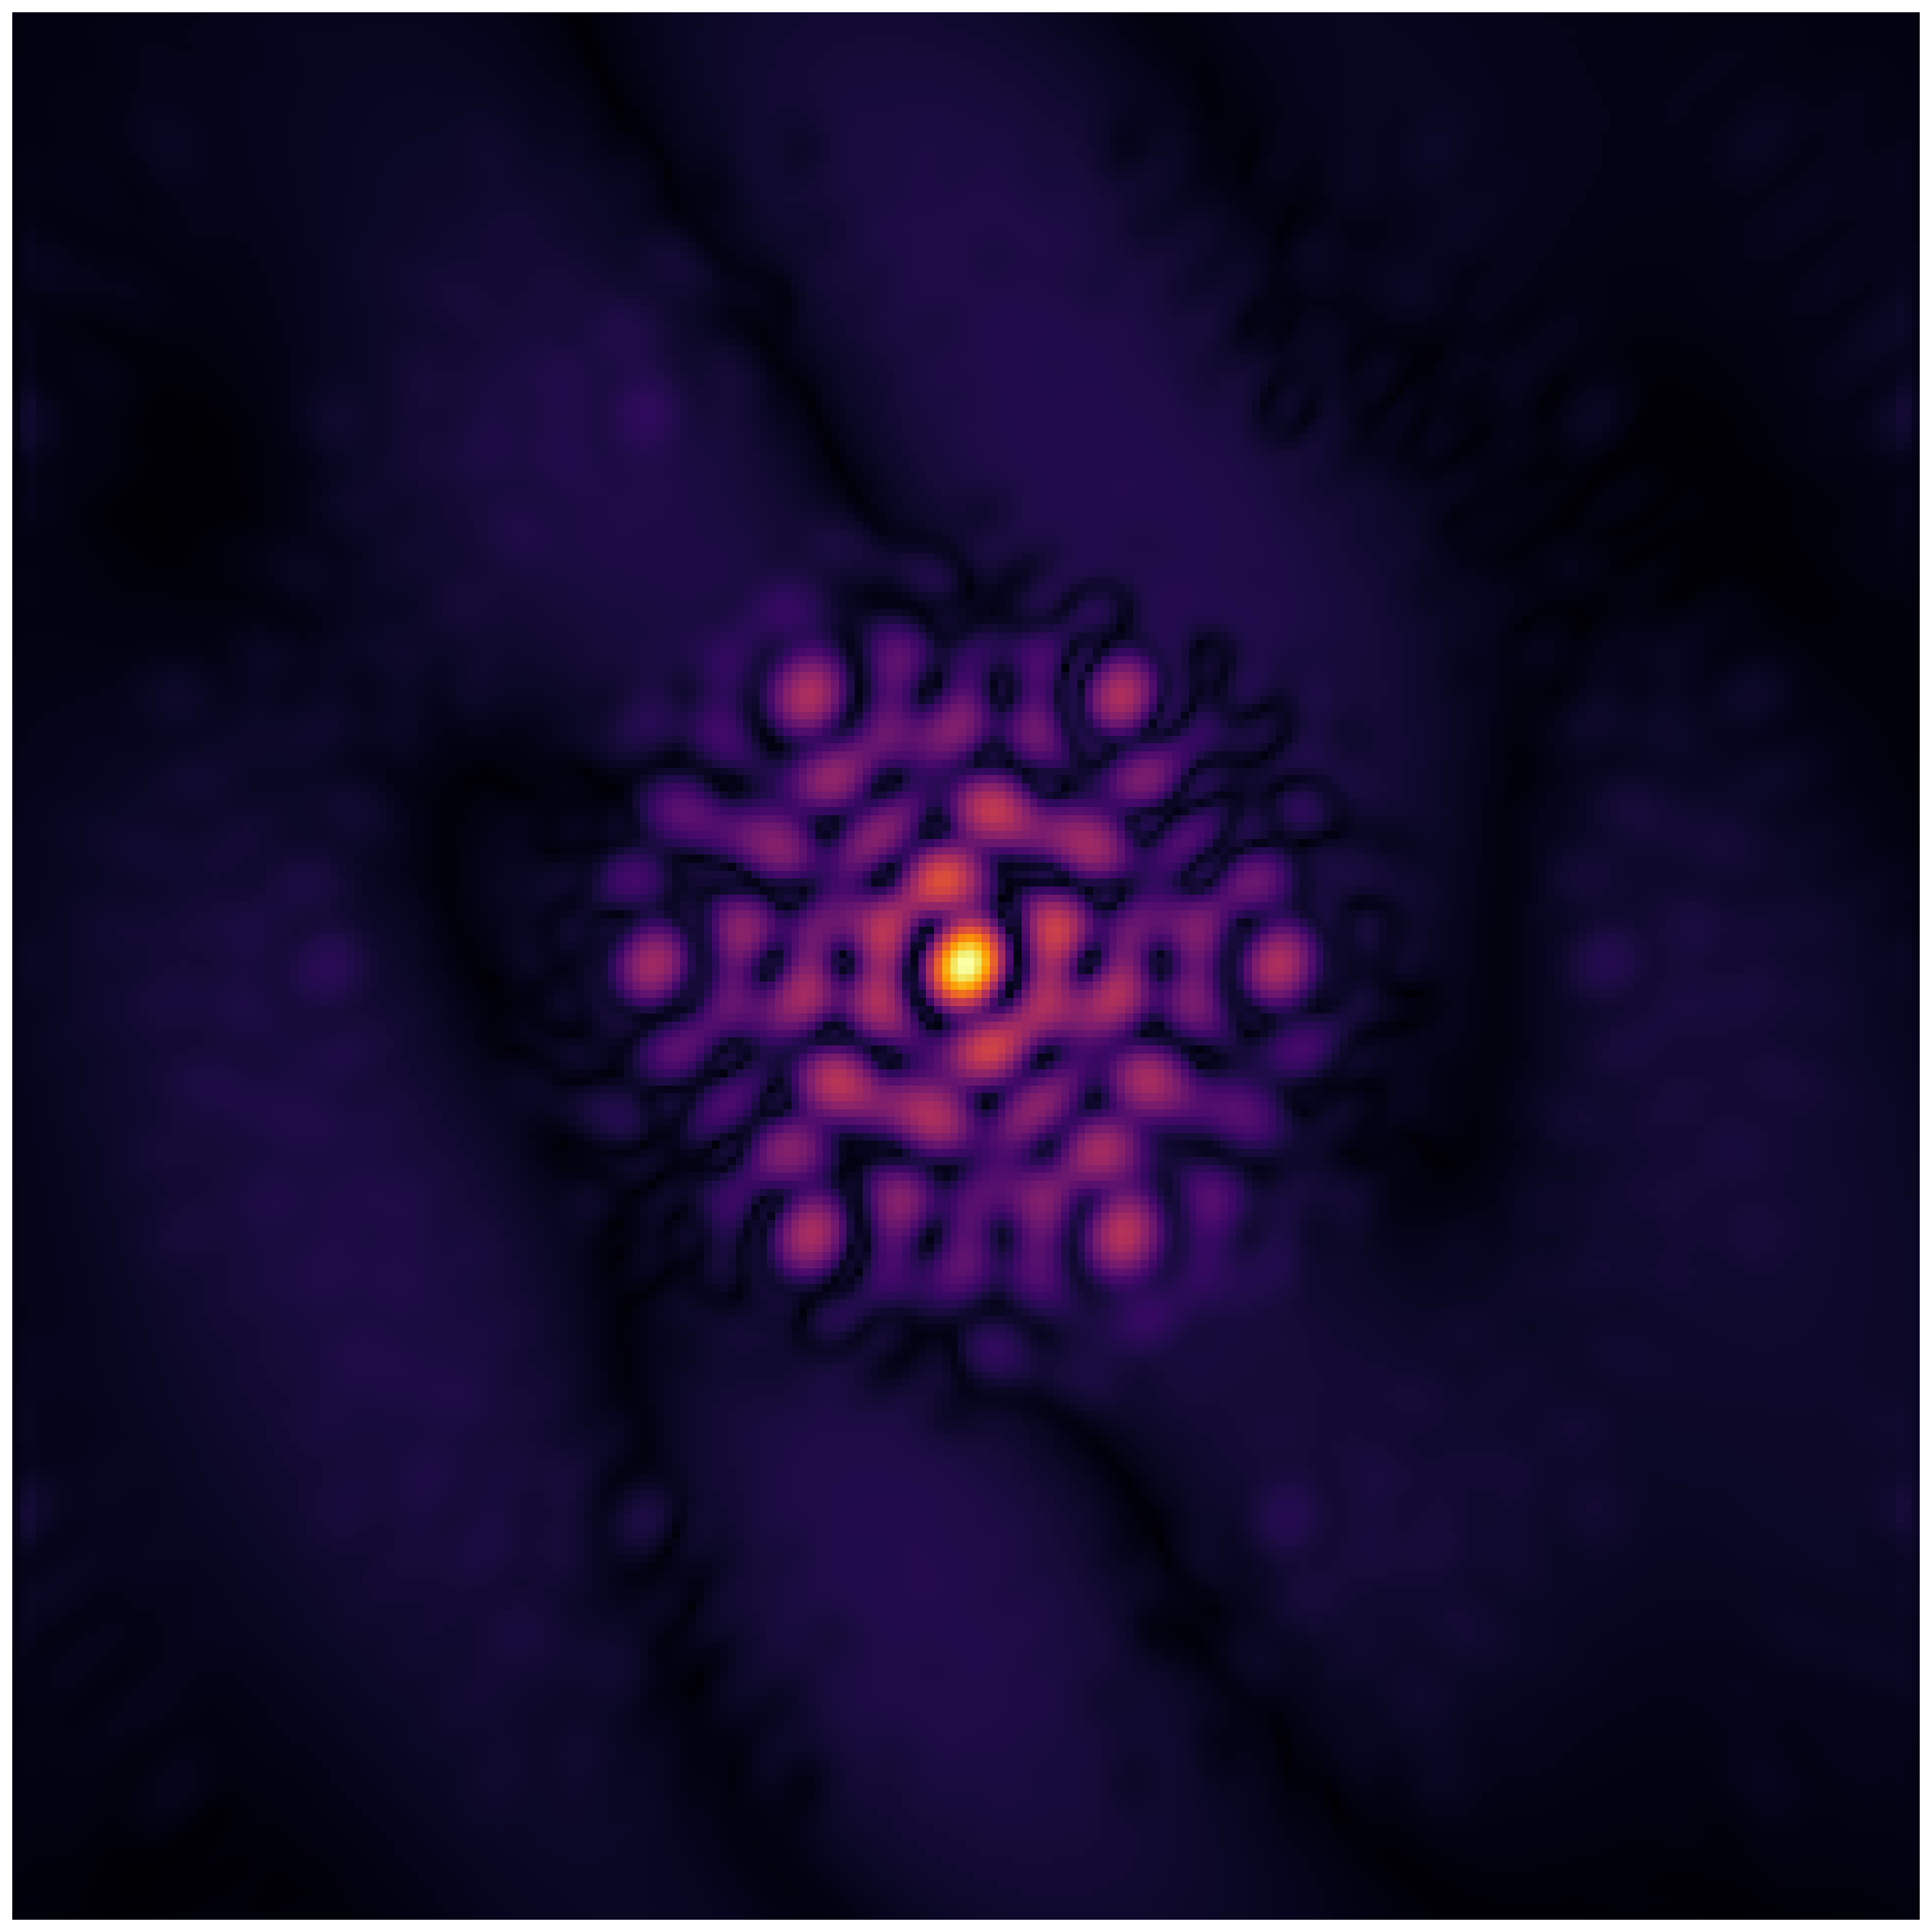

In [19]:
intfg = exp.model_vis(wfs, x).data

plt.figure(figsize=(8, 8))
plt.imshow(intfg, cmap="inferno", norm=mpl.colors.PowerNorm(0.5))
plt.axis("off")
plt.tight_layout()
plt.savefig(fig_path + "interferogram.png", dpi=300, bbox_inches="tight")
plt.show()

In [20]:
dlu.rad2deg(np.arctan(5 / 2))

Array(68.19859051, dtype=float64, weak_type=True)

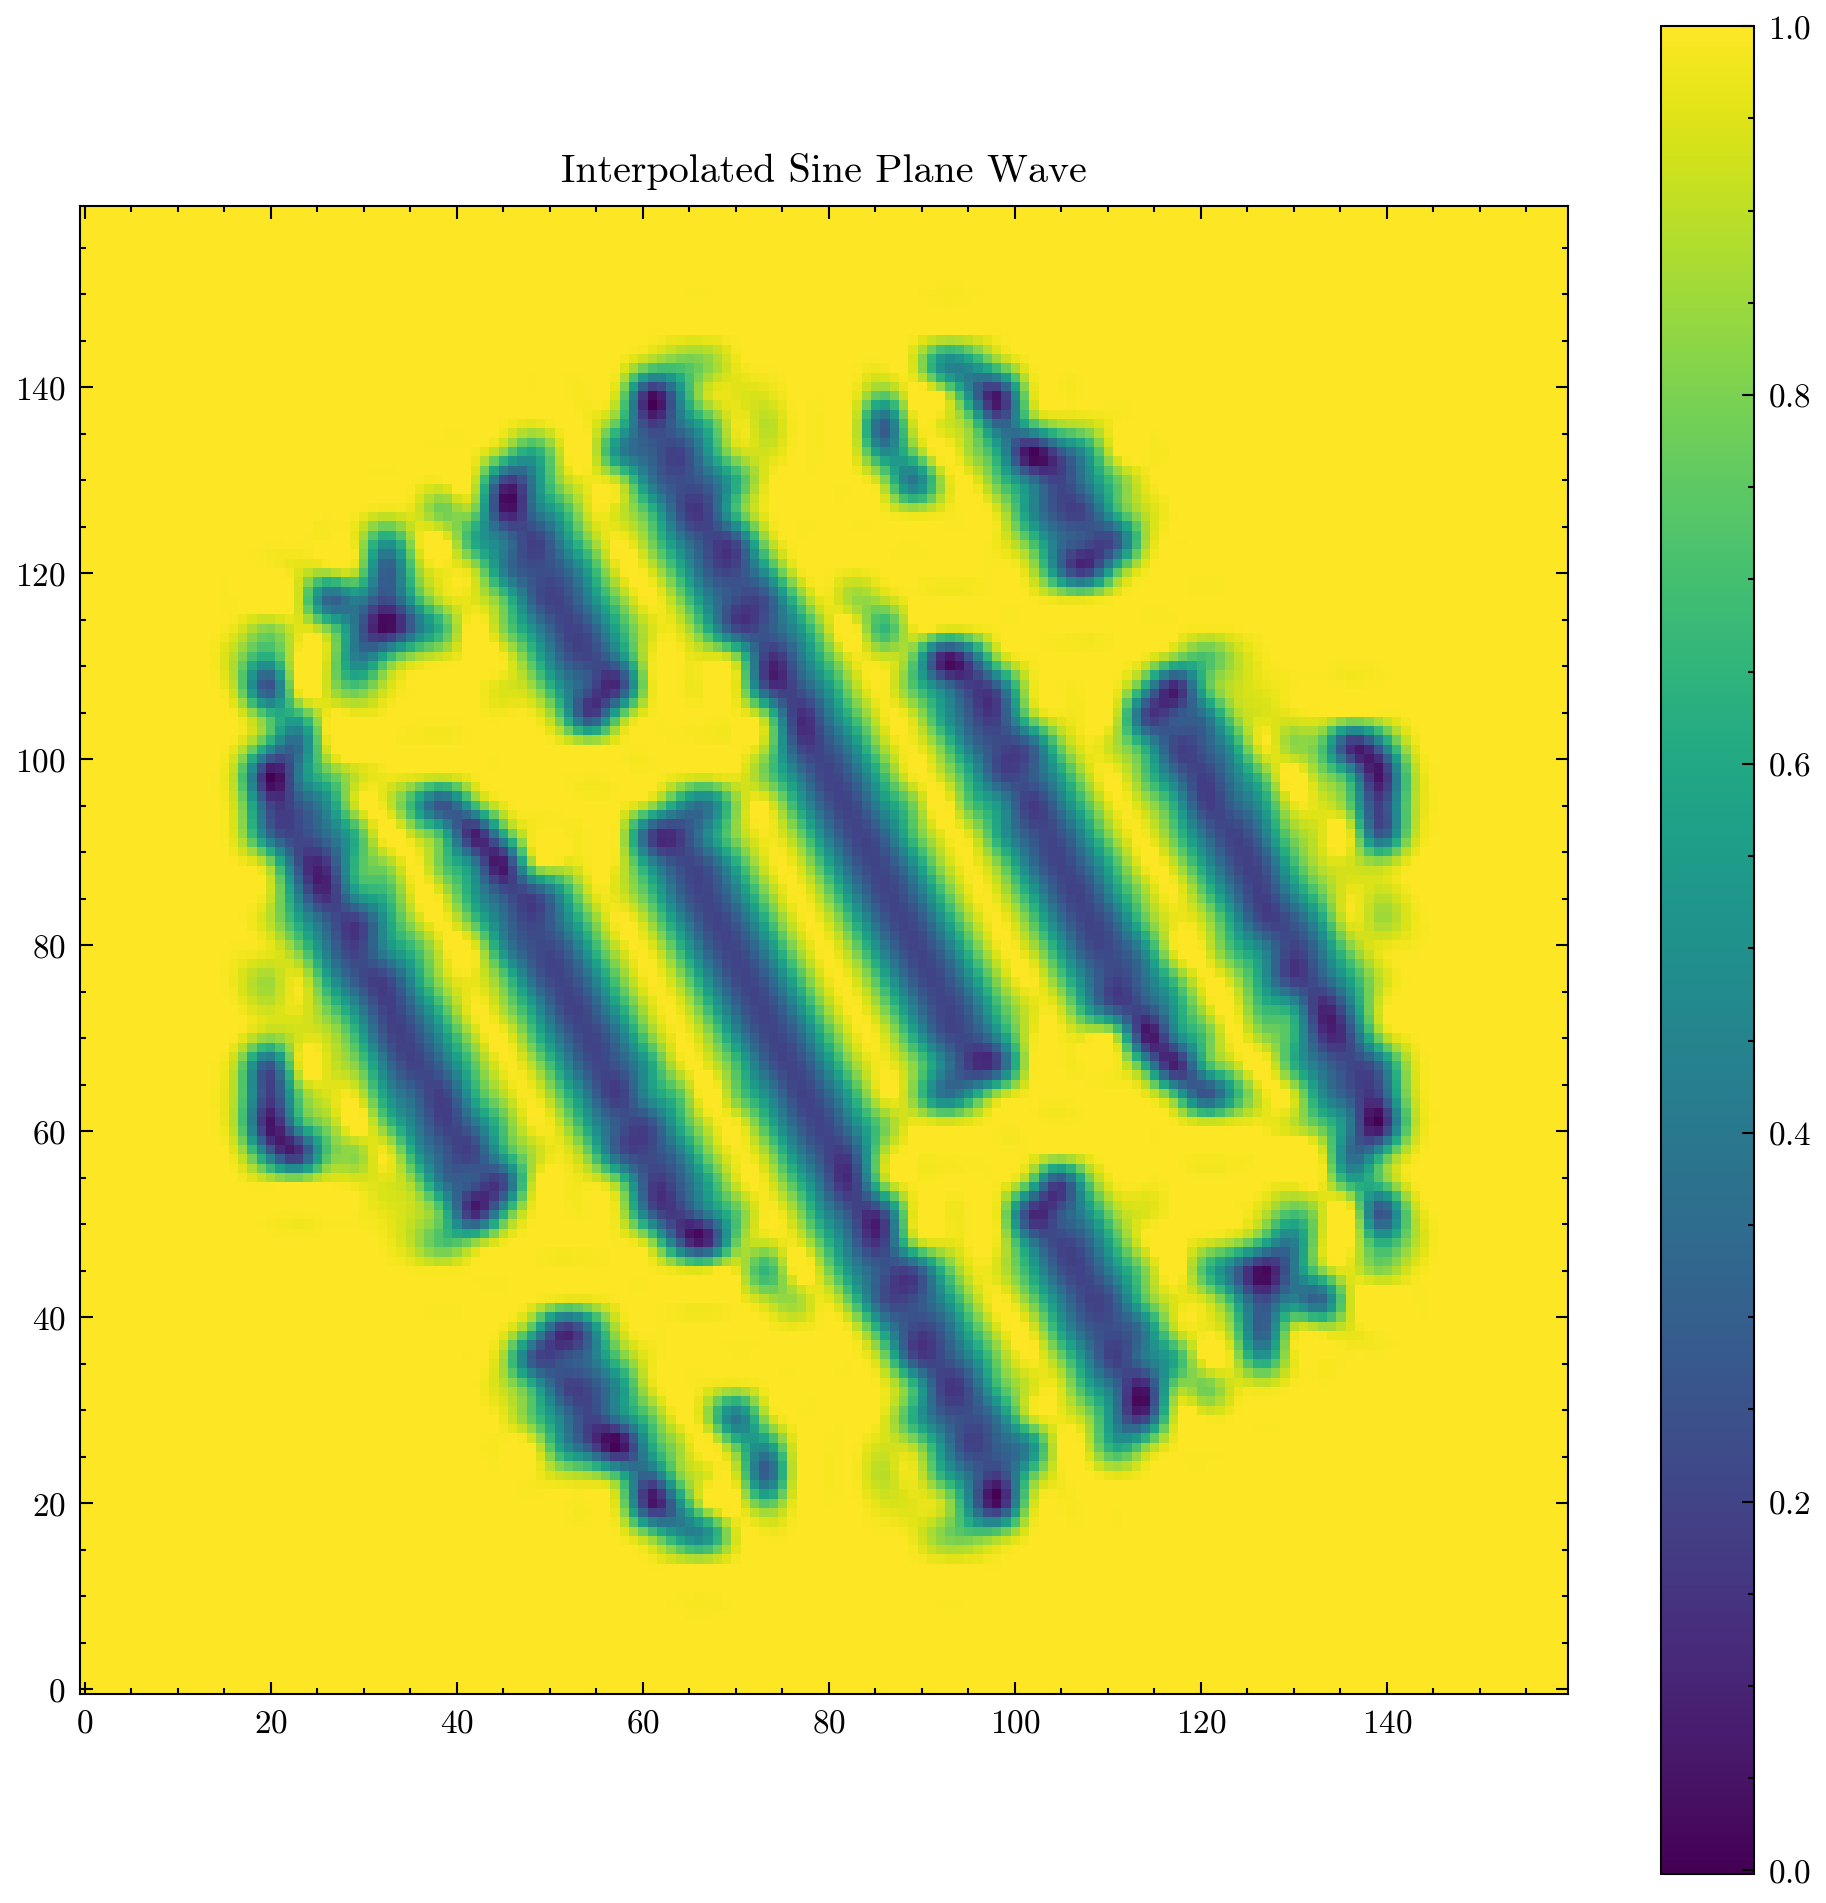

In [21]:
# Grid size
# nx, ny = 160, 160
nx, ny = 51, 51

# Spatial frequencies (cycles per unit length)
fy = 4  # frequency along x
fx = 2 * fy  # frequency along y

# Create grid
x = np.linspace(0, 1, nx)
y = np.linspace(0, 1, ny)
X, Y = dlu.pixel_coords(nx, 1.0)
sample_coords = np.stack([X, Y])  # shape: (2, 480, 480)


# Sine plane wave
depth = 0.01
wave = depth * np.cos(2 * np.pi * (fx * X + fy * Y)) + (1 - depth)

# plt.imshow(wave)
# plt.colorbar()
# plt.title("Sine Plane Wave")
# plt.show()

wave = np.log(wave)
V_amp = model.vis_model.V_amp["F480M"]
p = wave.flatten()[: wave.size // 2]

coeffs = np.dot(p, np.linalg.pinv(V_amp))
vis = np.dot(coeffs, V_amp)


vis_map = vis_to_im(vis, np.zeros_like(vis), (nx, ny))[0]
vis_map = np.exp(vis_map)


# Sample coordinates (grid of output image)
X2, Y2 = dlu.pixel_coords(160, 1.0)
knot_coords = np.stack([X2, Y2])  # shape: (2, 480, 480)

# Interpolate
wave = amigo.misc.interp(vis_map, sample_coords, knot_coords, method="cubic2", fill=1.0)
wave = np.clip(wave, None, 1.0)

n = 40
wave -= 1 - depth
wave *= n
wave += 1 - n * depth

plt.figure(figsize=(8, 8))
plt.imshow(wave, cmap="viridis")
plt.title("Interpolated Sine Plane Wave")
plt.colorbar()
plt.show()

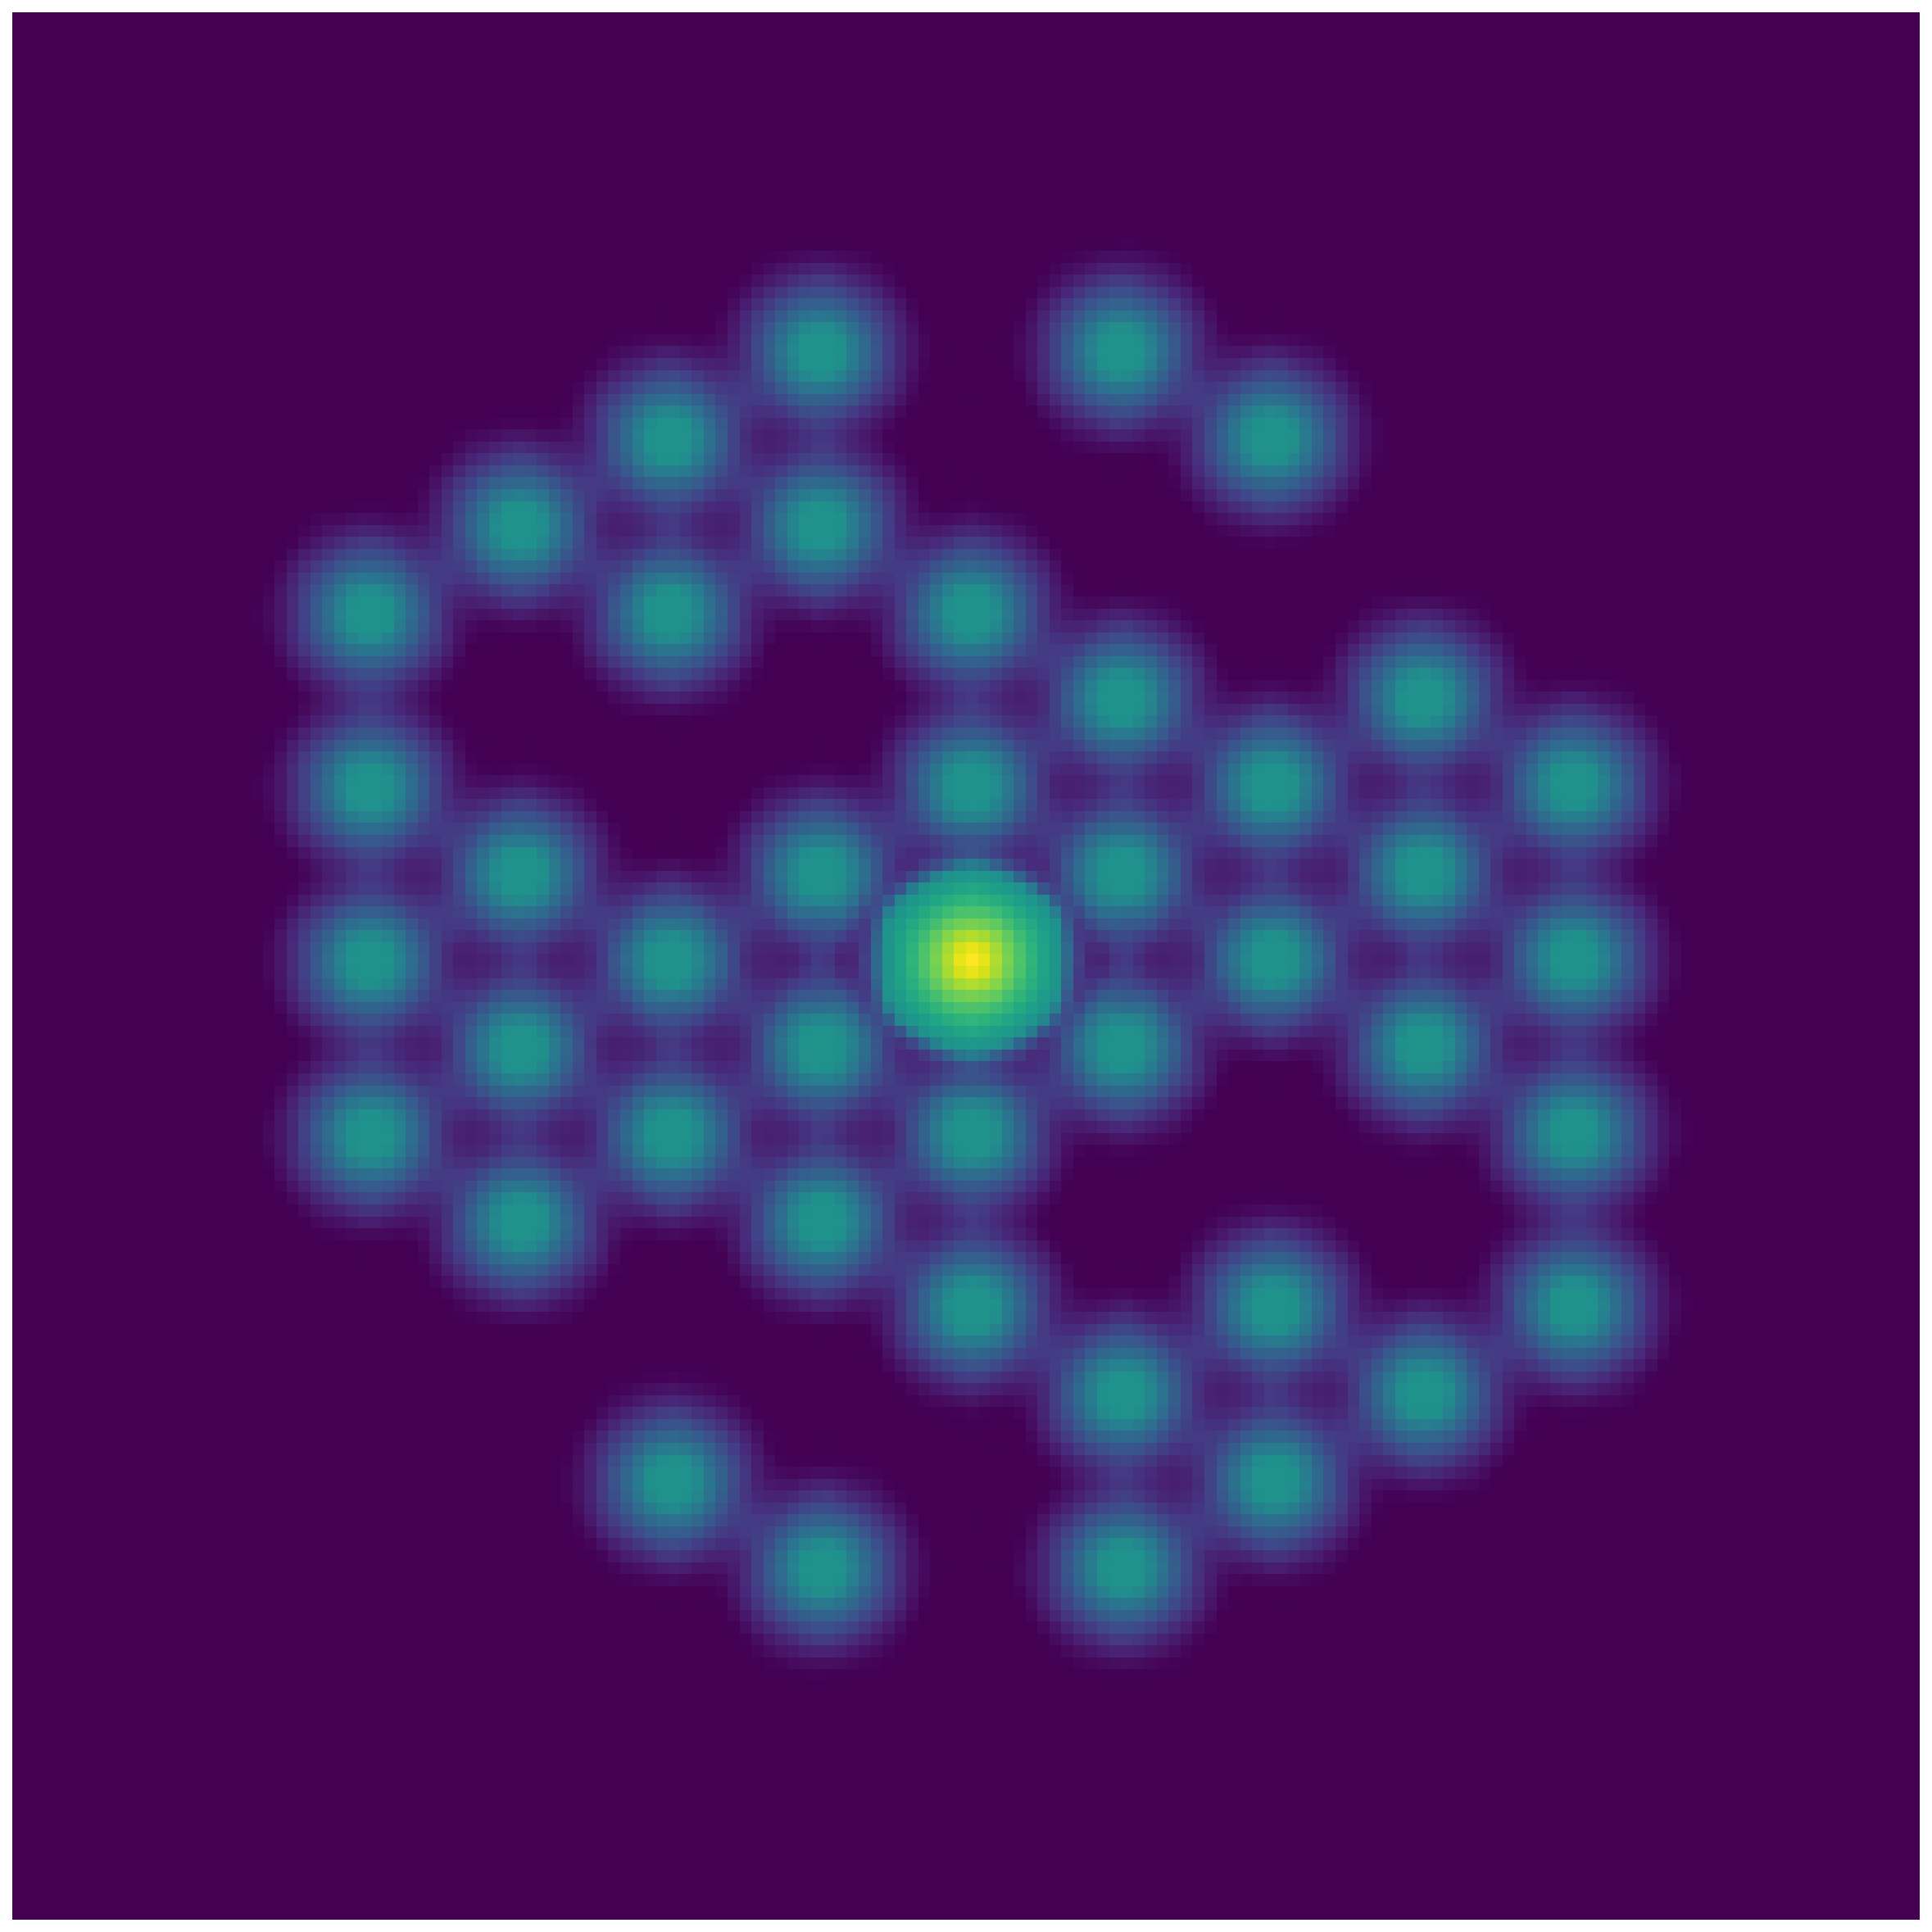

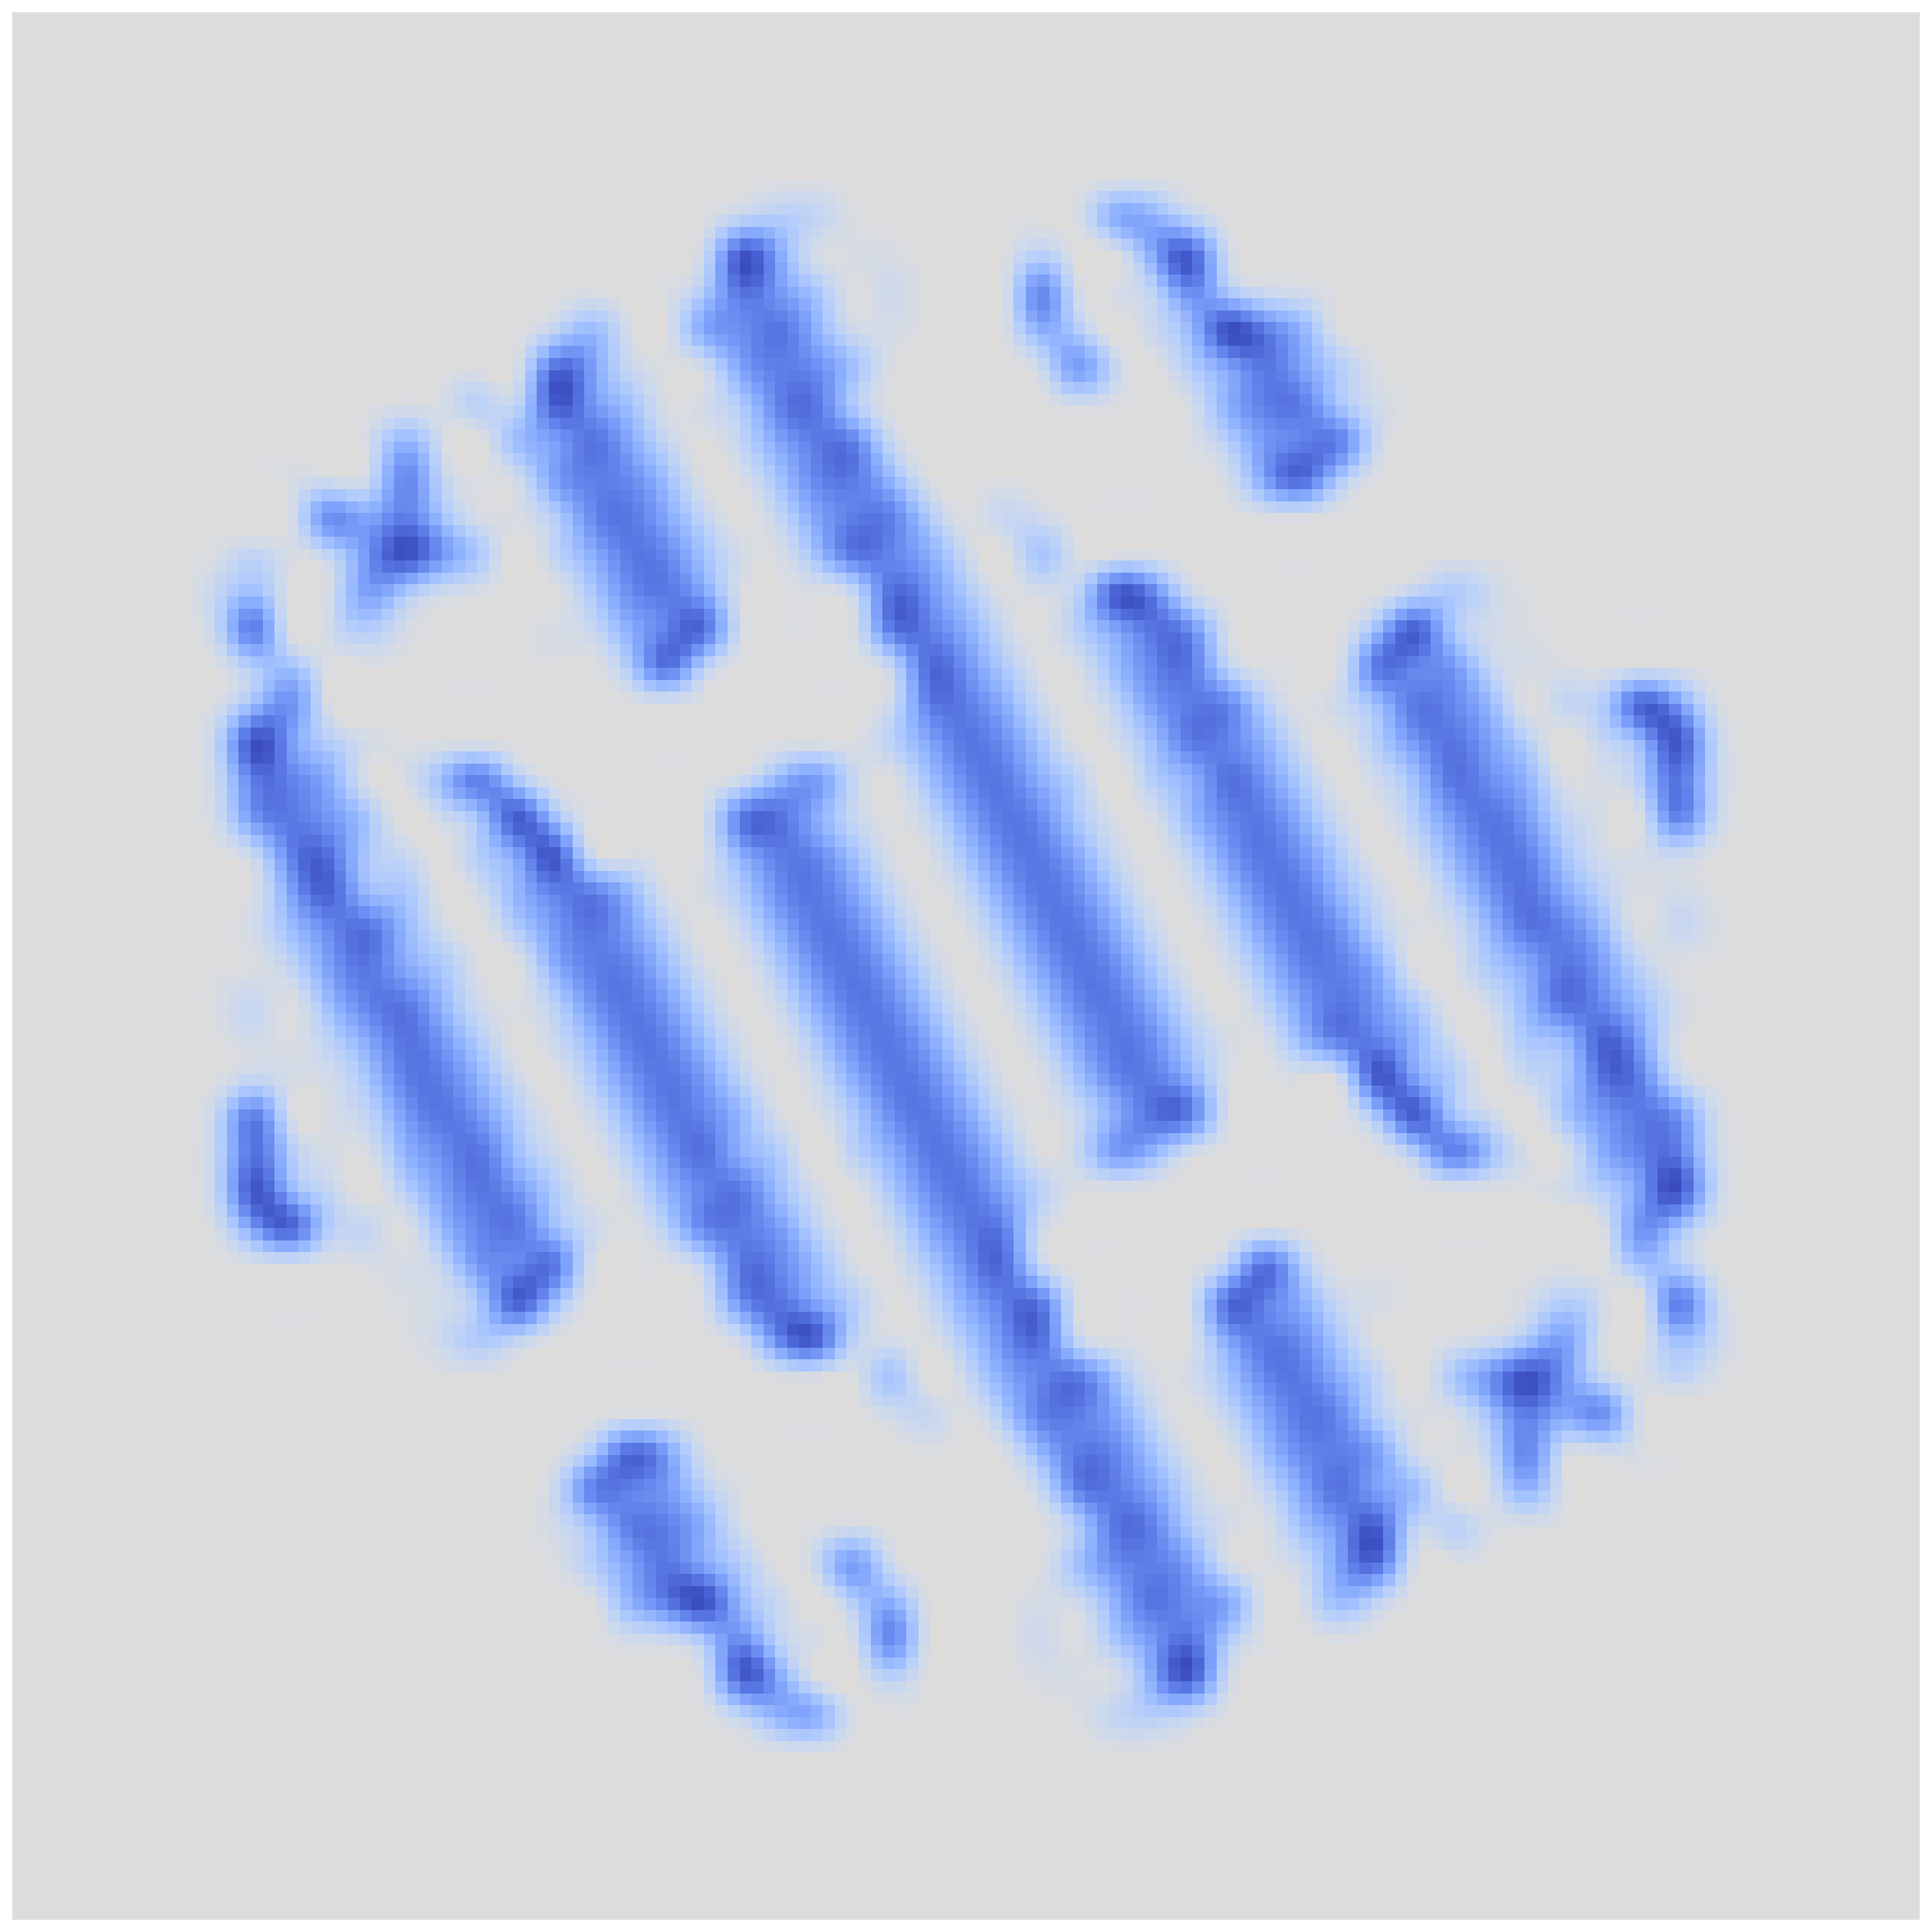

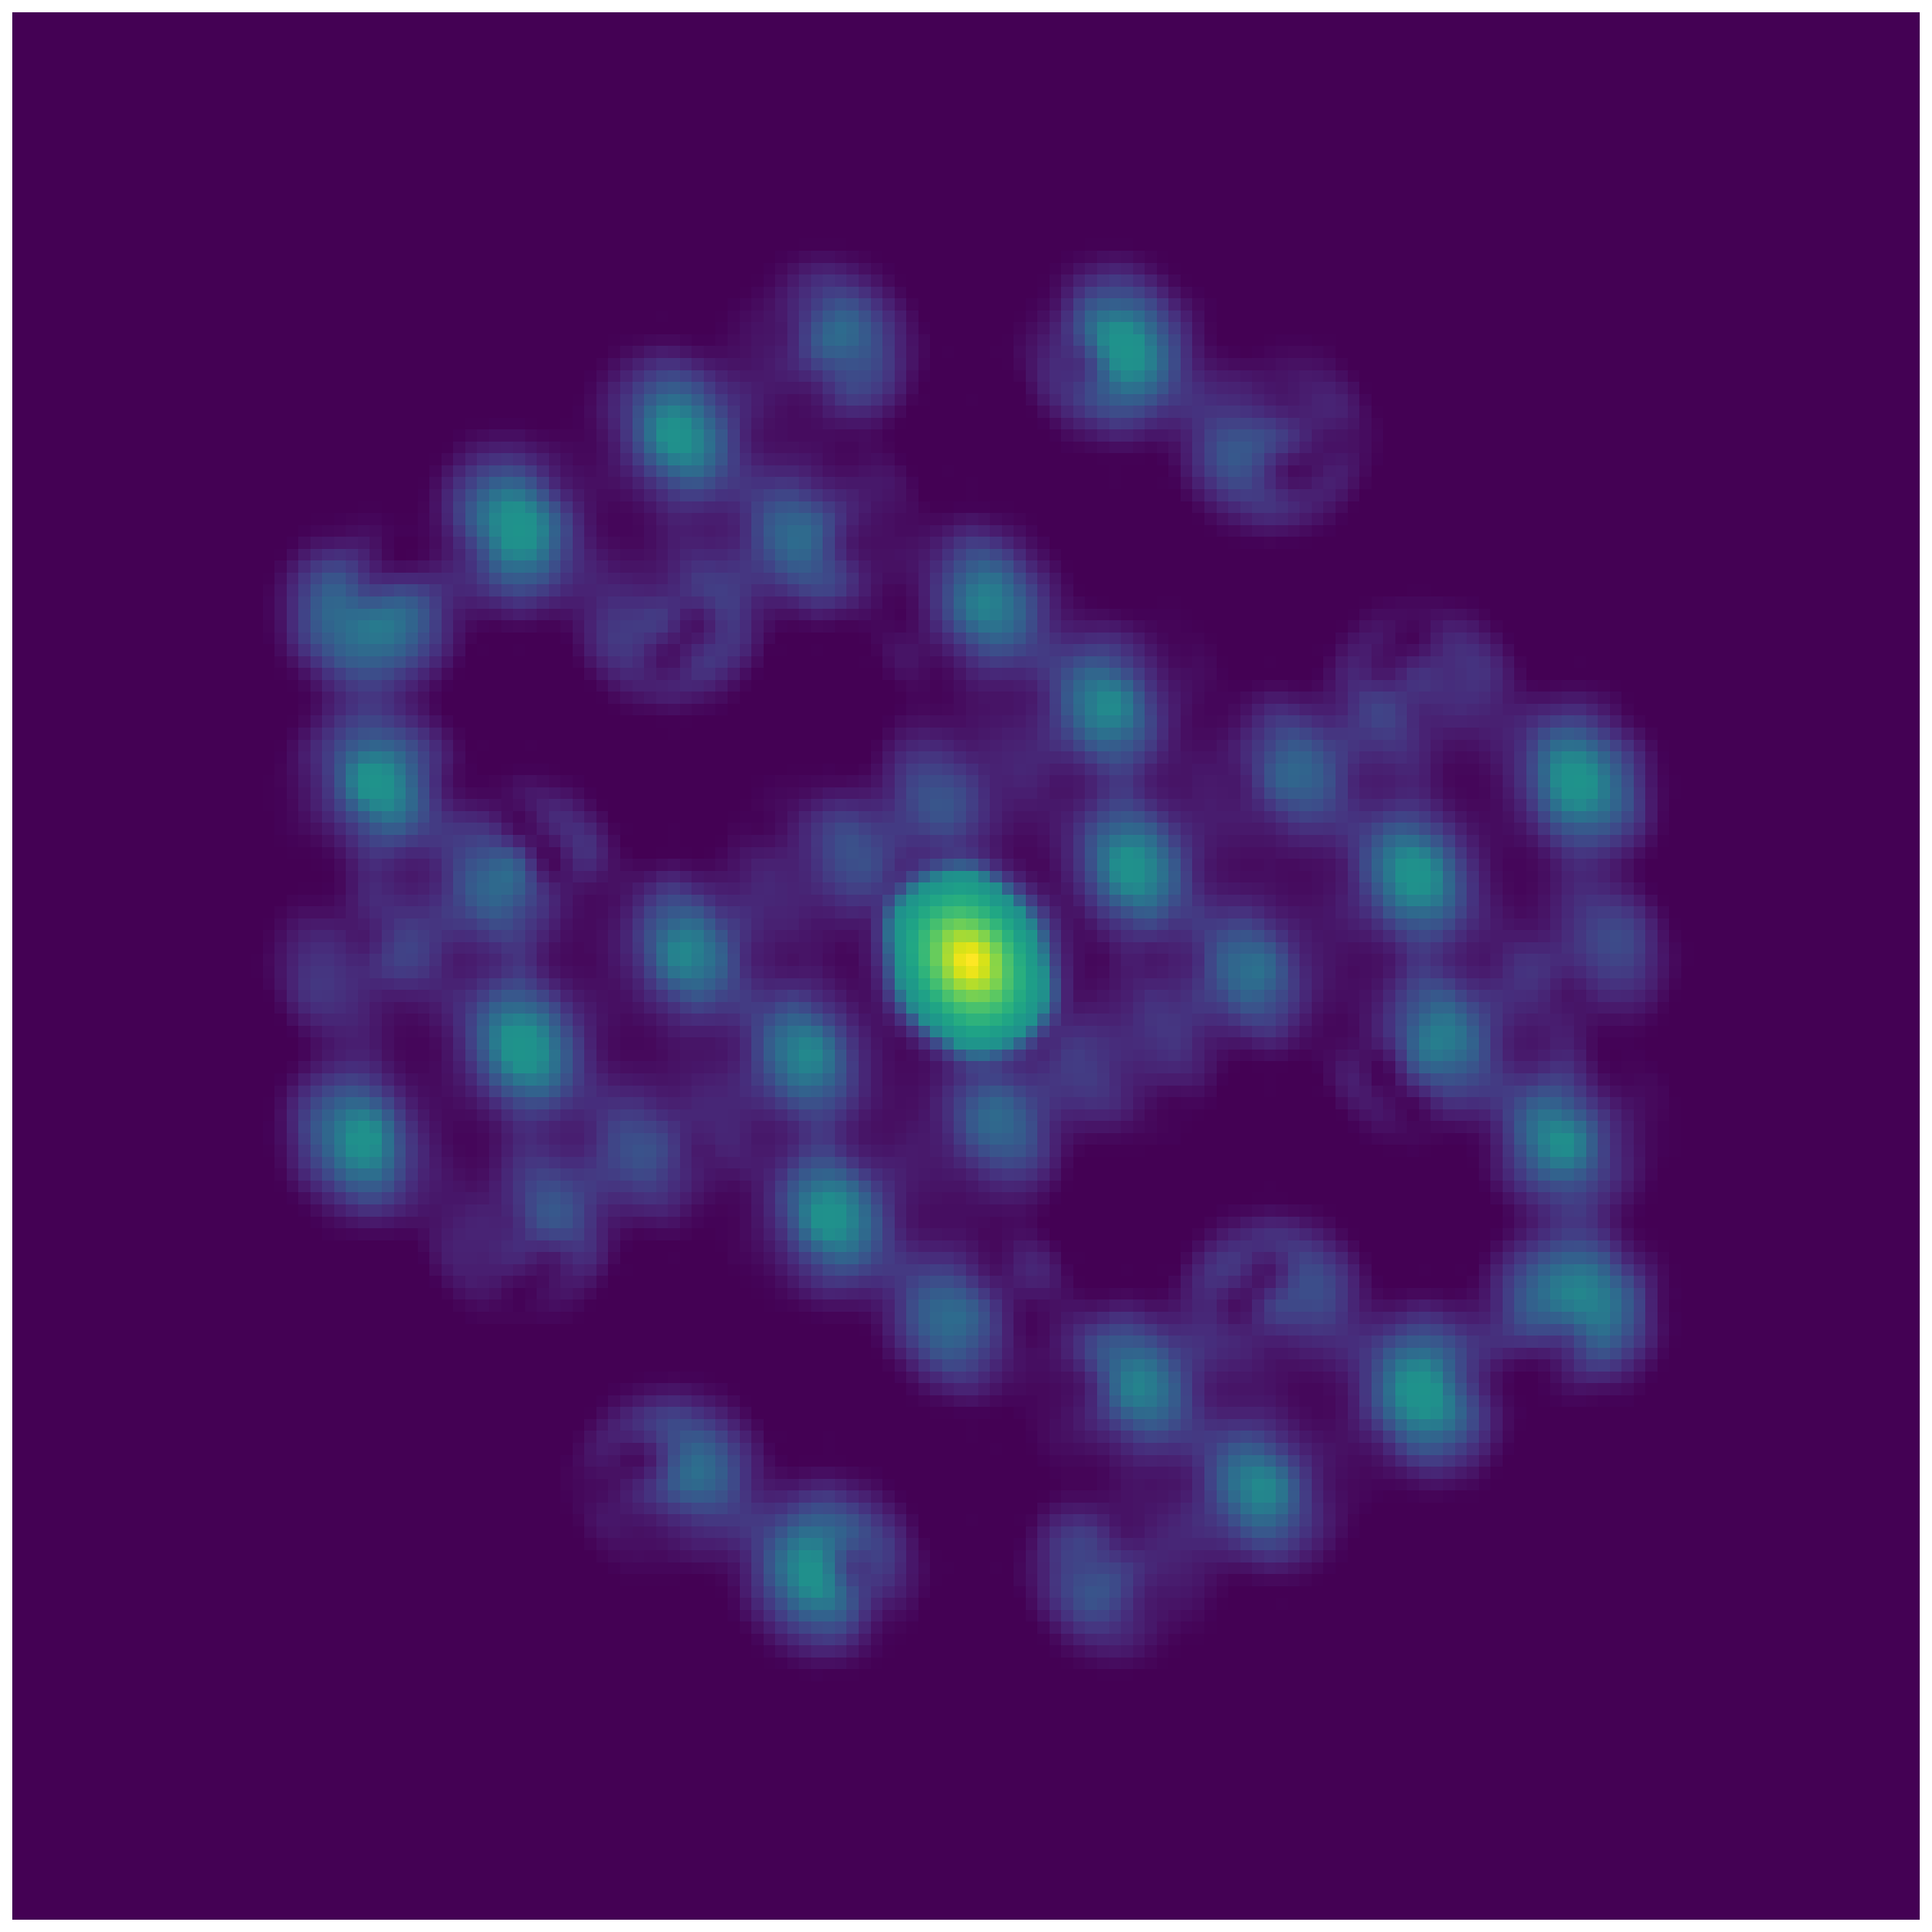

In [22]:
splodge = splodges[0]
log_amp = log_amps[0]
phase = phases[0]


c = splodge.shape[0] // 2
s = 80

splodge = splodge[c - s : c + s, c - s : c + s]
log_amp = log_amp[c - s : c + s, c - s : c + s]
phase = phase[c - s : c + s, c - s : c + s]

vis_map = np.exp(10 * log_amp + 1j * phase)
mid = 5e-4


plt.figure(figsize=(8, 8))
plt.imshow(
    np.abs(splodge),
    cmap="viridis",
    norm=mpl.colors.TwoSlopeNorm(mid),
    # norm=mpl.colors.PowerNorm(0.5),
)
plt.axis("off")
plt.tight_layout()
plt.savefig(fig_path + "splodge.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 8))
plt.imshow(wave, cmap="coolwarm", norm=mpl.colors.CenteredNorm(1))
# plt.imshow(np.abs(vis_map) ** 0.1, cmap="viridis", norm=mpl.colors.TwoSlopeNorm(1.0))
# plt.contour(
#     np.abs(vis_map),
#     levels=[1.0],
# )
# plt.colorbar()
plt.axis("off")
plt.tight_layout()
plt.savefig(fig_path + "vis_map.png", dpi=300, bbox_inches="tight")
plt.show()

# x = np.abs(splodge * vis_map)
x = np.abs(splodge * wave)
plt.figure(figsize=(8, 8))
plt.imshow(
    x,
    cmap="viridis",
    # norm=mpl.colors.PowerNorm(0.5),
    norm=mpl.colors.TwoSlopeNorm(mid),
)
# plt.contour(
#     x,
#     levels=[mid],
# )
plt.axis("off")
plt.tight_layout()
plt.savefig(fig_path + "vis_out.png", dpi=300, bbox_inches="tight")
plt.show()

In [23]:
import jax.numpy as np

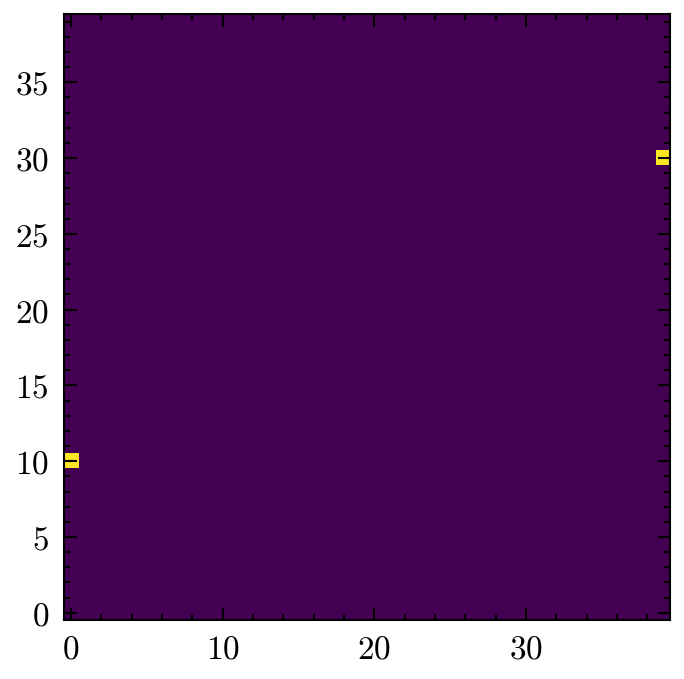

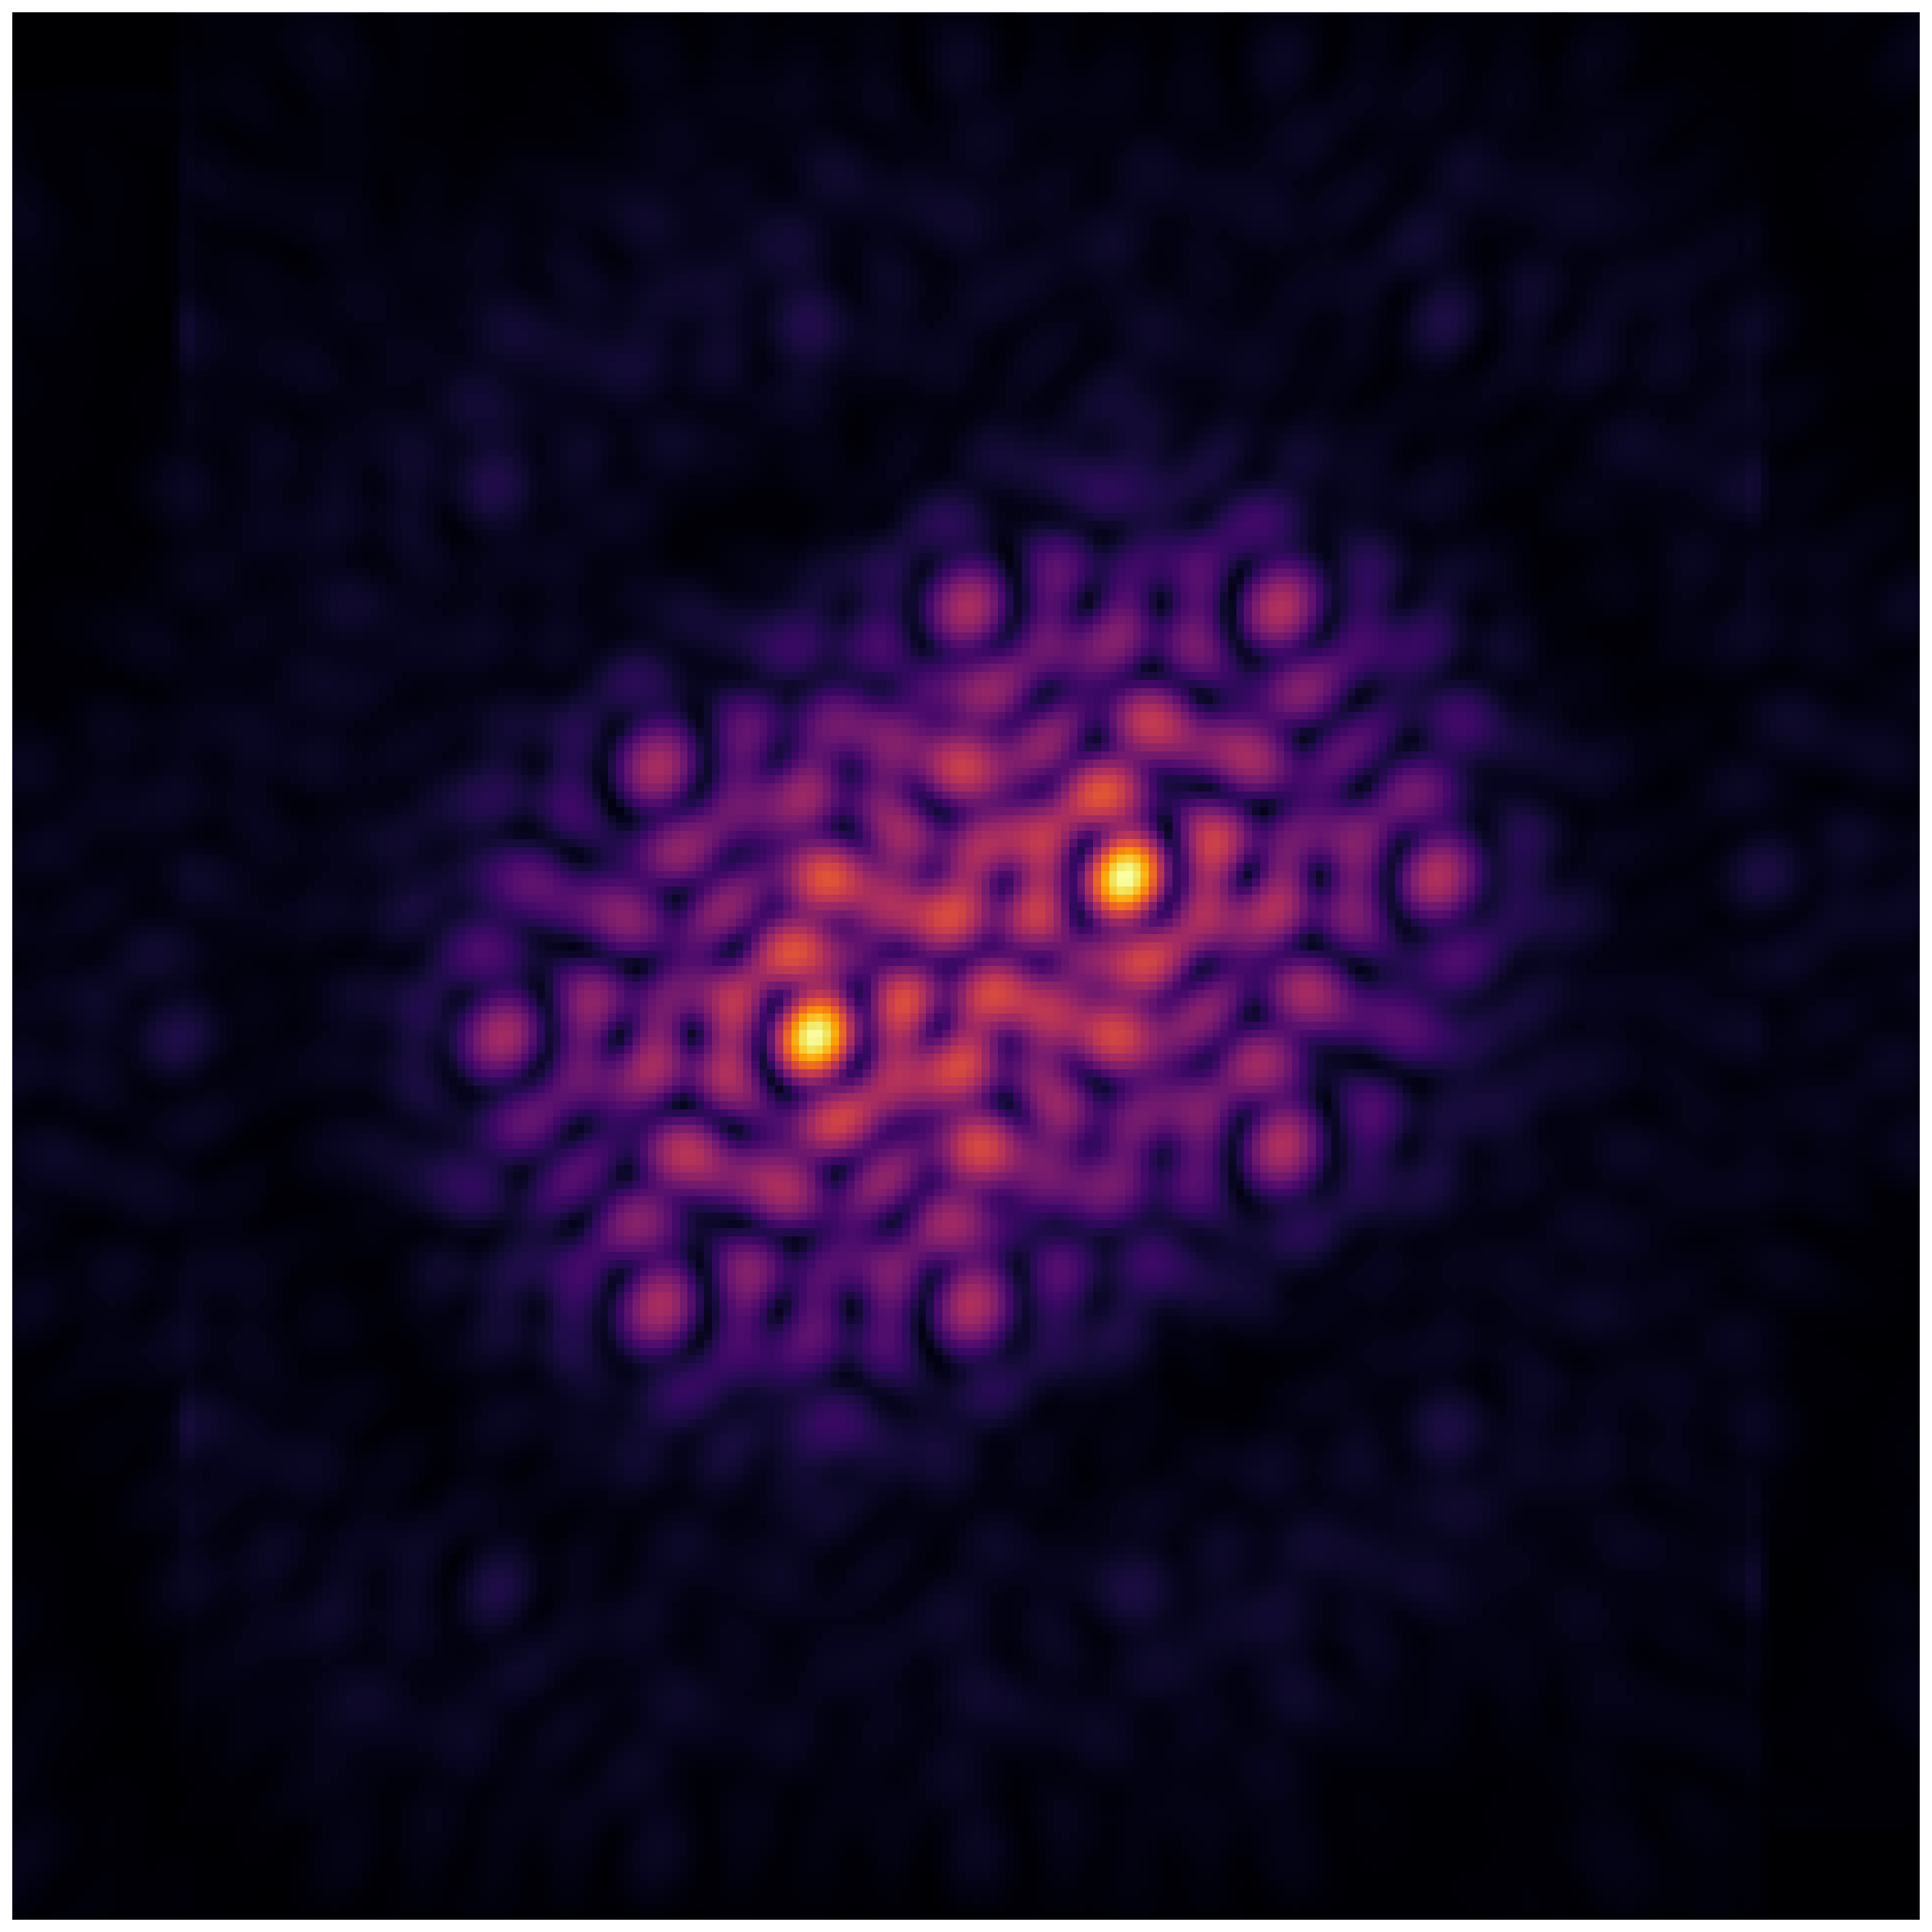

In [28]:
s = 40


two_stars = np.zeros((s, s)).at[s // 4, 0].set(1).at[-s // 4, -1].set(1)

plt.imshow(two_stars, cmap="viridis")

binary = psf.convolve(two_stars)

plt.figure(figsize=(8, 8))
plt.imshow(binary.data, norm=mpl.colors.PowerNorm(0.5), cmap="inferno")
plt.axis("off")
plt.tight_layout()
plt.savefig(fig_path + "binary.png", dpi=300, bbox_inches="tight")
plt.show()

In [25]:
import jax.numpy as np


def gaussian_kernel(size=5, sigma=1.0):
    """Returns a 2D Gaussian kernel array."""
    ax = np.arange(-size // 2 + 1.0, size // 2 + 1.0)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2.0 * sigma**2))
    kernel = kernel / np.sum(kernel)
    return kernel


gauss = gaussian_kernel(5, 0.5)

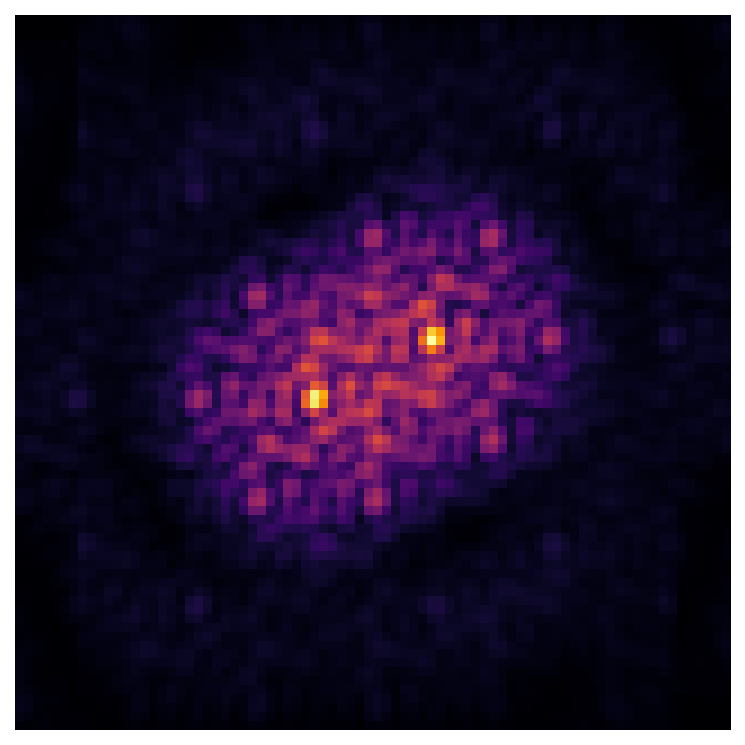

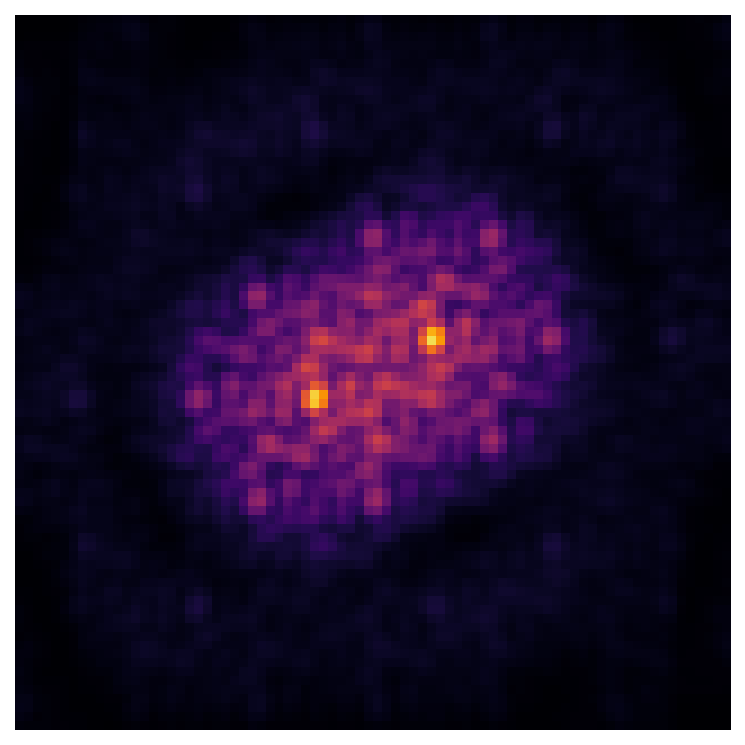

In [26]:
ds_binary = binary.downsample(3)

plt.imshow(ds_binary.data, norm=mpl.colors.PowerNorm(0.5), cmap="inferno")
plt.axis("off")
plt.tight_layout()
plt.savefig(fig_path + "ds_binary.png", dpi=300, bbox_inches="tight")
plt.show()

ds_binary2 = ds_binary.convolve(gauss)

plt.imshow(
    ds_binary2.data,
    norm=mpl.colors.PowerNorm(0.5, vmax=ds_binary.data.max()),
    cmap="inferno",
)
plt.axis("off")
plt.tight_layout()
plt.savefig(fig_path + "ds_binary2.png", dpi=300, bbox_inches="tight")
plt.show()

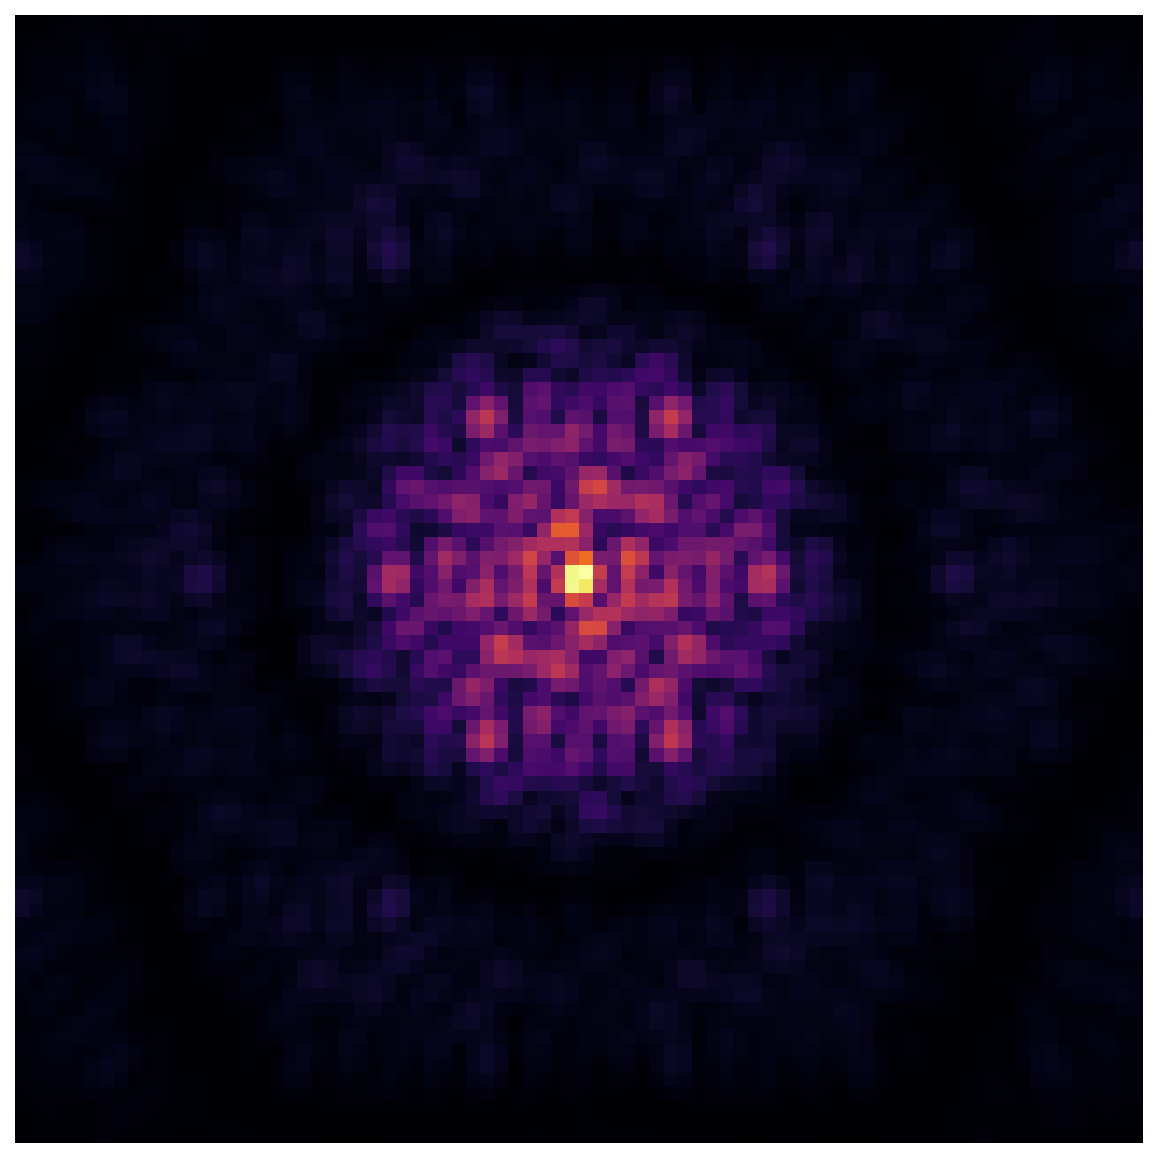

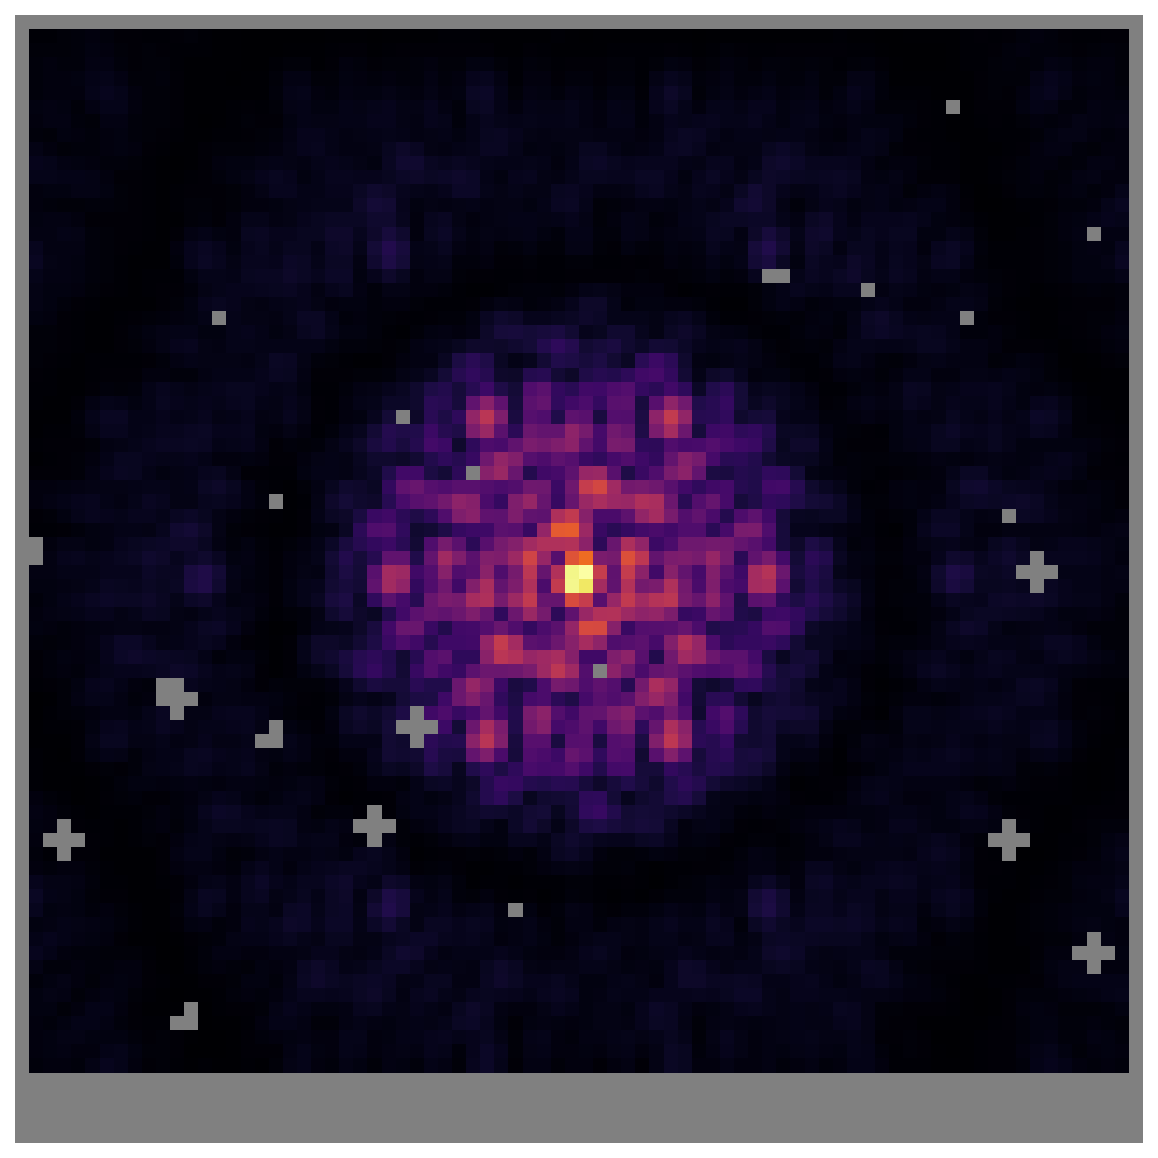

In [62]:
s = 50


# one_star = np.zeros((s, s)).at[s // 2, -1].set(1)

# plt.imshow(one_star, cmap="viridis")
# plt.colorbar()
# plt.show()

single = psf.downsample(3)

plt.figure(figsize=(4, 4))
plt.imshow(single.data, norm=mpl.colors.PowerNorm(0.5), cmap="inferno")
plt.axis("off")
plt.tight_layout()
plt.savefig(fig_path + "single.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(4, 4))
plt.imshow(
    np.where(exp.badpix, np.nan, single.data),
    norm=mpl.colors.PowerNorm(0.5),
    cmap=inferno,
)
plt.axis("off")
plt.tight_layout()
plt.savefig(fig_path + "single_bapix.png", dpi=300, bbox_inches="tight")
plt.show()